In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/data/home/anisha23/master-thesis/ETTh1.csv')
# df = pd.read_csv('/content/drive/My Drive/documents/ETTh1.csv')
print(df.shape)


(17420, 8)


/data/home/anisha23/master-thesis/deeplearn/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/data/home/anisha23/master-thesis/deeplearn/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [ ]:
from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()

features = ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL']

# df[features] = scaler.fit_transform(df[features])

In [ ]:
def create_sequences(data, target, seq_len=24, horizon=24):
    """
    data: [N, num_features]
    target: [N] (1D time series)
    """
    X, y = [], []
    for i in range(len(data) - seq_len - horizon + 1):
        X.append(data[i:i+seq_len])             # input window
        y.append(target[i+seq_len:i+seq_len+horizon])  # next H steps
    return np.array(X), np.array(y)


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

X, y = create_sequences(df[features].values, df['OT'])

print(X.shape)
print(y.shape)

(17373, 24, 6)
(17373, 24)


In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Split train+val into train and val (e.g., 80% train, 20% val of original 80%)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

# Print shapes
print("X_train shape: ", X_train.shape)
print("X_val shape:   ", X_val.shape)
print("X_test shape:  ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_val shape: ", y_val.shape)
print("y_test shape: ", y_test.shape)

X_train shape:  (11118, 24, 6)
X_val shape:    (2780, 24, 6)
X_test shape:   (3475, 24, 6)
y_train shape:  (11118, 24)
y_val shape:  (2780, 24)
y_test shape:  (3475, 24)


In [ ]:
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
horizon = 24
# ------------------------------
# 1. Fit scalers
# ------------------------------
input_scaler = StandardScaler()
target_scaler = StandardScaler()

# Scale inputs (fit on training set only)
X_train_scaled = input_scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_val_scaled   = input_scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
X_test_scaled  = input_scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

# Scale targets
y_train_scaled = target_scaler.fit_transform(y_train)   # shape: (n_samples, horizon)
y_val_scaled   = target_scaler.transform(y_val)
y_test_scaled  = target_scaler.transform(y_test)



# ------------------------------
# 2. Convert to tensors
# ------------------------------
X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_scaled = torch.tensor(y_train_scaled, dtype=torch.float32)

X_val = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_scaled = torch.tensor(y_val_scaled, dtype=torch.float32)

X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_scaled = torch.tensor(y_test_scaled, dtype=torch.float32)

# ------------------------------
# 3. Create datasets & dataloaders
# ------------------------------
train_ds = TensorDataset(X_train, y_train_scaled)
val_ds   = TensorDataset(X_val, y_val_scaled)
test_ds  = TensorDataset(X_test, y_test_scaled)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=64)
test_dl  = DataLoader(test_ds, batch_size=64)


In [ ]:
print("y_train shape:", y_train.shape)
print("Scaled y_train mean:", y_train_scaled.mean(axis=0))
print("Scaled y_train std:", y_train_scaled.std(axis=0))


y_train shape: (11118, 24)
Scaled y_train mean: tensor([ 1.8871e-09, -1.7156e-09, -8.5778e-11, -1.2867e-09, -2.0587e-09,
         4.2889e-10, -1.2009e-09,  1.7156e-09,  1.8871e-09, -1.8871e-09,
        -1.7156e-09, -2.2302e-09,  3.0880e-09,  5.1467e-10, -5.1467e-10,
        -1.0293e-09,  3.0880e-09,  1.5440e-09, -1.2009e-09, -3.4311e-10,
        -1.2009e-09, -1.0293e-09, -1.0293e-09, -3.7742e-09])
Scaled y_train std: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [ ]:
print("\n(Input tensors)")
print("  Min:", torch.min(X_train).item(), "Max:", torch.max(X_train).item(),
      "Mean:", torch.mean(X_train.float()).item(), "Std:", torch.std(X_train.float()).item())

print("\n(Target tensors)")
print("  Min:", torch.min(y_train_scaled).item(), "Max:", torch.max(y_train_scaled).item(),
      "Mean:", torch.mean(y_train_scaled.float()).item(), "Std:", torch.std(y_train_scaled.float()).item())


(Input tensors)
  Min: -4.319881439208984 Max: 4.719793319702148 Mean: -3.526408609566545e-10 Std: 1.0000003576278687

(Target tensors)
  Min: -2.037824869155884 Max: 3.806688070297241 Mean: 0.0 Std: 1.0000019073486328


In [ ]:
# import torch
# import torch.nn as nn
# import numpy as np
# from sklearn.cluster import KMeans
# from collections import defaultdict

# class ProSeNetRegressor(nn.Module):
#     def __init__(self, input_dim, hidden_dim, num_prototypes, train_loader, horizon, dropout_prob=0.1, device='cpu'):
#         super(ProSeNetRegressor, self).__init__()
#         self.device = device

#         # Encoder (same as before)
#         self.encoder = nn.LSTM(
#             input_dim, hidden_dim, num_layers=3,
#             batch_first=True, bidirectional=True, dropout=dropout_prob
#         )
#         self.dropout = nn.Dropout(dropout_prob)

#         # Regression head: output a single continuous value
#         self.fc = nn.Linear(num_prototypes, horizon)

#         # Initialize model on device
#         self.to(self.device)

#          # Initialize prototypes (no class labels in regression)
#         self.prototypes = nn.Parameter(self.kmeans_init(train_loader, num_prototypes, hidden_dim))


#     def kmeans_init(self, train_loader, num_prototypes, hidden_dim):
#         """Cluster all embeddings into prototypes (no per-class separation)."""
#         all_embeddings = []
#         self.eval()

#         with torch.no_grad():
#             for data, _ in train_loader:   # ignore labels (since regression target is continuous)
#                 data = data.to(self.device)
#                 _, (h_n, _) = self.encoder(data)
#                 h = torch.cat((h_n[-2], h_n[-1]), dim=1)  # [B, hidden_dim*2]
#                 all_embeddings.append(h.cpu().numpy())

#         all_embeddings = np.vstack(all_embeddings)

#         # Run KMeans across all embeddings
#         kmeans = KMeans(n_clusters=num_prototypes, random_state=42)
#         kmeans.fit(all_embeddings)
#         prototypes = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)

#         return prototypes.to(self.device)

#     def forward(self, x):
#         x = x.to(self.device)
#         _, (h_n, _) = self.encoder(x)
#         h = torch.cat((h_n[-2], h_n[-1]), dim=1)  # [B, hidden_dim*2]
#         h = self.dropout(h)

#         # Compute similarity to prototypes
#         dists = torch.cdist(h, self.prototypes, p=2)  # [B, num_prototypes]
#         sims = torch.exp(-dists ** 2)
#         #sims = torch.softmax(-dists, dim=1)

#         # Regression output
#         out = self.fc(sims)  # [B, H]
#         return out.squeeze(-1), sims, h   # return scalar predictions


In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.cluster import KMeans

class ProSeNetRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_prototypes, train_loader, horizon, dropout_prob=0.1, device='cpu'):
        super(ProSeNetRegressor, self).__init__()
        self.device = device

        # Encoder
        self.encoder = nn.LSTM(
            input_dim, hidden_dim, num_layers=3,
            batch_first=True, bidirectional=True, dropout=dropout_prob
        )
        self.dropout = nn.Dropout(dropout_prob)

        # Forecasting head: now takes hidden state directly
        out_dim = hidden_dim * 2  # bidirectional → hidden_dim*2
        # self.fc = nn.Linear(out_dim, horizon)
        self.fc = nn.Linear(out_dim + num_prototypes, horizon)
#         self.fc = nn.Linear(hidden_dim * 2 + num_prototypes, horizon)


        # Initialize model on device
        self.to(self.device)

        # Initialize prototypes (moved to correct device!)
        proto_tensor = self.kmeans_init(train_loader, num_prototypes, hidden_dim)
        self.prototypes = nn.Parameter(proto_tensor.to(self.device))

    def kmeans_init(self, train_loader, num_prototypes, hidden_dim):
        """Cluster embeddings into prototypes (CPU for sklearn, then back to torch)."""
        all_embeddings = []
        self.eval()

        with torch.no_grad():
            for data, _ in train_loader:
                data = data.to(self.device)                # ✅ FIX: ensure input is on same device as encoder
                _, (h_n, _) = self.encoder(data)
                h = torch.cat((h_n[-2], h_n[-1]), dim=1)   # [B, hidden_dim*2]
                all_embeddings.append(h.cpu().numpy())     # move back to CPU for sklearn

        all_embeddings = np.vstack(all_embeddings)

        # Run KMeans on CPU
        kmeans = KMeans(n_clusters=num_prototypes, random_state=42)
        kmeans.fit(all_embeddings)
        prototypes = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)

        return prototypes   # will be moved to self.device in __init__

    def forward(self, x):
        x = x.to(self.device)
        _, (h_n, _) = self.encoder(x)
        h = torch.cat((h_n[-2], h_n[-1]), dim=1)   # [B, hidden_dim*2]
        h = self.dropout(h)

        # Prototype similarities (for interpretability)
        dists = torch.cdist(h, self.prototypes, p=2)  # [B, num_prototypes]
#         sims = torch.exp(-dists ** 2)
        # sims = torch.softmax(-dists, dim=1)
        τ = 0.1  # smaller -> sharper, higher similarities
        sims = torch.softmax(-dists / τ, dim=1)


        # Forecast from hidden state
#         h_forecast = self.fc(h)
#         proto_forecasts = self.fc(self.prototypes)
#         weighted_proto_forecast = torch.matmul(sims, proto_forecasts)  # [B, horizon]

        # Combine both: part from encoder, part from prototypes
#         out = 0.5 * h_forecast + 0.5 * weighted_proto_forecast
        combined = torch.cat([h, sims], dim=1)
        out = self.fc(combined)

        return out, sims, h


In [ ]:
## loss decrease over time as embeddings move closer to their nearest prototypes.

def clustering_loss(h, prototypes):
    h = F.normalize(h, dim=-1)
    prototypes = F.normalize(prototypes, dim=-1)

    # print(f"embeddings :\n{h}")
    # print(f"prototypes :\n{prototypes}")
    dists = torch.cdist(h, prototypes, p=2) ** 2  # square it explicitly
    # print(f"distance : \n{dists}")
    min_dists = torch.min(dists, dim=1)[0]
    return torch.mean(min_dists)

## every prototype should have at least one close data point

def evidence_loss(h, prototypes):
    h = F.normalize(h, dim=-1)
    prototypes = F.normalize(prototypes, dim=-1)
    dists = torch.cdist(prototypes, h, p=2) ** 2  # squared distances
    min_dists = torch.min(dists, dim=1)[0]        # min over encoded instances
    return torch.mean(min_dists)

## Penalizes too-close prototypes to avoid redundancy.
# Previous value of d_min = 2.5. Tried d_min=3.0. But its not giving good result
# Tried with 2.7 also, but the better result is with d_min = 2.5

# d_min = 1.0, 1.5,

def diversity_loss(prototypes, d_min=1.0):
    prototypes = F.normalize(prototypes, dim=-1)
    dists = torch.cdist(prototypes, prototypes)
    mask = torch.triu(torch.ones_like(dists), diagonal=1)
    penalty = F.relu(d_min - dists) ** 2
    return torch.sum(penalty * mask) / (prototypes.shape[0] * (prototypes.shape[0] - 1) / 2)

#     return torch.sum(penalty * mask)

def sparsity_loss(fc):
    return torch.norm(fc.weight, p=1)



In [ ]:
model = ProSeNetRegressor(input_dim=6, hidden_dim=64, num_prototypes=5,  train_loader=train_dl, horizon=24, device=device)
model.to(device)

ProSeNetRegressor(
  (encoder): LSTM(6, 64, num_layers=3, batch_first=True, dropout=0.1, bidirectional=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=133, out_features=24, bias=True)
)

In [ ]:
def compute_intra_inter_distances(dtw_matrix, cluster_labels, medoids):
    # Organize cluster members
    clusters = defaultdict(list)
    for idx, label in enumerate(cluster_labels):
        clusters[label].append(idx)

    intra_distances = {}
    for label, indices in clusters.items():
        medoid_idx = medoids[label]
        total_distance = 0.0
        for i in indices:
            if i != medoid_idx:
                total_distance += dtw_matrix[medoid_idx, i]

        avg_intra_dist = total_distance / (len(indices)-1) if len(indices) > 1 else 0.0
        intra_distances[label] = avg_intra_dist

    # Compute Inter-cluster distances between medoids
    inter_distances = {}
    for (label1, medoid1), (label2, medoid2) in combinations(medoids.items(), 2):
        inter_distances[(label1, label2)] = dtw_matrix[medoid1, medoid2]

    return intra_distances, inter_distances


In [ ]:
def project_prototypes(model, dataloader):
    model.eval()
    with torch.no_grad():
        all_inputs = []
        all_targets = []
        all_embeddings = []

        for inputs, targets  in dataloader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            _, _, h = model(inputs)
            all_inputs.append(inputs)
            all_targets.append(targets)
            all_embeddings.append(h)

        all_inputs = torch.cat(all_inputs, dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        all_embeddings = torch.cat(all_embeddings, dim=0)

        closest_inputs = []
        closest_targets = []

        for i in range(model.prototypes.shape[0]):
            proto = model.prototypes[i].unsqueeze(0)
            dists = torch.norm(all_embeddings - proto, dim=1)
            closest_idx = torch.argmin(dists)
            closest_input = all_inputs[closest_idx]
            closest_target = all_targets[closest_idx]
            closest_inputs.append(closest_input)
            closest_targets.append(closest_target.cpu())

        return closest_inputs, closest_targets


In [ ]:
# # previous value of diversity penalty is 1.0
# def training(model, train_loader, val_loader,criterion,optimizer,num_epochs,lambda_c, lambda_e, lambda_d):
#     train_losses = []
#     val_losses = []
#     train_accs = []
#     val_accs = []
#     sim_scores_per_epoch = []

#     mse_losses, clust_losses, evid_losses, div_losses = [], [], [], []
#     all_embeddings = []
#     all_labels = []

#     model.to(device)

#     for epoch in range(num_epochs):
#         model.train()
#         running_train_loss = 0.0
#         train_correct = 0.0
#         train_total = 0.0

#         mse_loss_epoch = 0.0
#         clust_loss_epoch = 0.0
#         evid_loss_epoch = 0.0
#         div_loss_epoch = 0.0

#         sim_scores_epoch = []
#         epoch_embeddings = []
#         epoch_labels = []


#         for batch in train_loader:
#             inputs, targets = batch
#             inputs, targets = inputs.to(device), targets.to(device).float()
#             preds, sims, h = model(inputs)

#             mse_loss = criterion(preds, targets.float())
#             # print(f"ce loss : {ce_loss}")
#             clust_loss = clustering_loss(h, model.prototypes)
#             # print(f"clust loss : {clust_loss}")
#             evid_loss = evidence_loss(h, model.prototypes)
#             # print(f"evid loss : {evid_loss}")
#             # div_loss = diversity_loss(model.prototypes)
#             div_loss = diversity_loss(model.prototypes)
#             # print(f"div loss : {div_loss}")
#             # l1_loss = sparsity_loss(model.fc)

#             # lambda_e = lambda_e_schedule(epoch)
#             loss = (mse_loss +
#                     lambda_c * clust_loss +
#                     lambda_e * evid_loss +
#                     lambda_d * div_loss )

#             optimizer.zero_grad()
#             loss.backward()
#             torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#             optimizer.step()

#             if hasattr(model, 'fc'):
#                 for param in model.fc.parameters():
#                     param.data.clamp_(min=0.0)

#             running_train_loss += loss.item()
#             mse_loss_epoch += mse_loss.item()
#             clust_loss_epoch += clust_loss.item()
#             evid_loss_epoch += evid_loss.item()
#             div_loss_epoch += div_loss.item()

#             sim_scores_epoch.append(sims.detach().cpu())
#             epoch_embeddings.append(h.detach().cpu())
#             epoch_labels.append(targets.detach().cpu())

#         avg_train_loss = running_train_loss / len(train_loader)
#         train_losses.append(avg_train_loss)

#         mse_losses.append(mse_loss_epoch / len(train_loader))
#         clust_losses.append(clust_loss_epoch / len(train_loader))
#         evid_losses.append(evid_loss_epoch / len(train_loader))
#         div_losses.append(div_loss_epoch / len(train_loader))

#         sim_scores_per_epoch.append(torch.cat(sim_scores_epoch, dim=0))
#         all_embeddings = torch.cat(epoch_embeddings, dim=0)
#         all_labels = torch.cat(epoch_labels, dim=0)

#         # ---- Validation ----
#         model.eval()
#         running_val_loss = 0.0
#         val_correct = 0
#         val_total = 0

#         with torch.no_grad():
#             for batch in val_loader:
#                 inputs, targets = batch
#                 inputs, targets = inputs.to(device), targets.to(device).float()
#                 preds, sims, h = model(inputs)
#                 val_loss = criterion(preds, targets.float())
#                 running_val_loss += val_loss.item()

#         avg_val_loss = running_val_loss / len(val_loader)
#         val_losses.append(avg_val_loss)

#         print(f"Epoch {epoch+1}/{num_epochs} "
#               f"Total Train Loss: {avg_train_loss:.4f}"
#               f"| Val Loss: {avg_val_loss:.4f}")

#     return (train_losses, val_losses, mse_losses, clust_losses, evid_losses, div_losses,
#             sim_scores_per_epoch, all_embeddings, all_labels)


In [ ]:
# Updated training function for multi-horizon targets
def training(model, train_loader, val_loader, criterion, optimizer,
             num_epochs, lambda_c, lambda_e, lambda_d, target_scaler):
    train_losses = []
    val_losses = []
    train_mse_orig = []   # Track train MSE in original scale
    val_mse_orig = []     # Track val MSE in original scale

    mse_losses, clust_losses, evid_losses, div_losses = [], [], [], []
    sim_scores_per_epoch = []
    all_embeddings, all_labels = [], []

    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        mse_loss_epoch = 0.0
        clust_loss_epoch = 0.0
        evid_loss_epoch = 0.0
        div_loss_epoch = 0.0

        sim_scores_epoch = []
        epoch_embeddings = []
        epoch_labels = []
        orig_preds_epoch = []
        orig_targets_epoch = []

        # -----------------------------
        # Training loop
        # -----------------------------
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device).float()  # targets shape: (B, horizon)
            preds, sims, h = model(inputs)  # preds shape: (B, horizon)

            # Losses in scaled space
            mse_loss = criterion(preds, targets)
            clust_loss = clustering_loss(h, model.prototypes)
            evid_loss = evidence_loss(h, model.prototypes)
            div_loss = diversity_loss(model.prototypes)

            loss = (mse_loss +
                    lambda_c * clust_loss +
                    lambda_e * evid_loss +
                    lambda_d * div_loss)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            if hasattr(model, 'fc'):
                for param in model.fc.parameters():
                    param.data.clamp_(min=0.0)

            # Track scaled-space losses
            running_train_loss += loss.item()
            mse_loss_epoch += mse_loss.item()
            clust_loss_epoch += clust_loss.item()
            evid_loss_epoch += evid_loss.item()
            div_loss_epoch += div_loss.item()

            sim_scores_epoch.append(sims.detach().cpu())
            epoch_embeddings.append(h.detach().cpu())
            epoch_labels.append(targets.detach().cpu())

            # ---- NEW: track inverse-transformed predictions (multi-horizon) ----
            # preds_np and targets_np will be shape (B, horizon)
            preds_np = preds.detach().cpu().numpy()
            targets_np = targets.detach().cpu().numpy()

            # inverse_transform expects shape (B, horizon) if fitted on (n_samples, horizon)
            preds_orig = target_scaler.inverse_transform(preds_np)    # shape (B, horizon)
            targets_orig = target_scaler.inverse_transform(targets_np) # shape (B, horizon)

            # Flatten and accumulate for epoch-level metrics
            orig_preds_epoch.extend(preds_orig.reshape(-1))   # length B*horizon
            orig_targets_epoch.extend(targets_orig.reshape(-1))

        # Average training losses
        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        mse_losses.append(mse_loss_epoch / len(train_loader))
        clust_losses.append(clust_loss_epoch / len(train_loader))
        evid_losses.append(evid_loss_epoch / len(train_loader))
        div_losses.append(div_loss_epoch / len(train_loader))

        # safe concat (only if non-empty)
        if len(sim_scores_epoch) > 0:
            sim_scores_per_epoch.append(torch.cat(sim_scores_epoch, dim=0))
        else:
            sim_scores_per_epoch.append(torch.tensor([]))

        if len(epoch_embeddings) > 0:
            all_embeddings = torch.cat(epoch_embeddings, dim=0)
        else:
            all_embeddings = torch.tensor([])

        if len(epoch_labels) > 0:
            all_labels = torch.cat(epoch_labels, dim=0)
        else:
            all_labels = torch.tensor([])

        # Compute train MSE in original scale (flattened across all horizons)
        train_mse_epoch_orig = np.mean((np.array(orig_preds_epoch) -
                                        np.array(orig_targets_epoch)) ** 2)
        train_mse_orig.append(train_mse_epoch_orig)

        # -----------------------------
        # Validation loop
        # -----------------------------
        model.eval()
        running_val_loss = 0.0
        orig_preds_val = []
        orig_targets_val = []

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device).float()
                preds, sims, h = model(inputs)

                # Loss in scaled space
                val_loss = criterion(preds, targets)
                running_val_loss += val_loss.item()

                # inverse transform (multi-horizon)
                preds_np = preds.detach().cpu().numpy()      # (B, horizon)
                targets_np = targets.detach().cpu().numpy()  # (B, horizon)

                preds_orig = target_scaler.inverse_transform(preds_np)
                targets_orig = target_scaler.inverse_transform(targets_np)

                orig_preds_val.extend(preds_orig.reshape(-1))
                orig_targets_val.extend(targets_orig.reshape(-1))

        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Compute val MSE in original scale
        val_mse_epoch_orig = np.mean((np.array(orig_preds_val) -
                                      np.array(orig_targets_val)) ** 2)
        val_mse_orig.append(val_mse_epoch_orig)

        # -----------------------------
        # Logging
        # -----------------------------
        print(f"Epoch {epoch+1}/{num_epochs} "
              f"| Train Loss (scaled): {avg_train_loss:.6f} "
              f"| Val Loss (scaled): {avg_val_loss:.6f} "
              f"| Train MSE (orig): {train_mse_epoch_orig:.6f} "
              f"| Val MSE (orig): {val_mse_epoch_orig:.6f}")

    return (train_losses, val_losses, mse_losses, clust_losses, evid_losses,
            div_losses, sim_scores_per_epoch, all_embeddings, all_labels,
            train_mse_orig, val_mse_orig)


In [ ]:
# # for n_prototypes in [7, 8, 9, 10, 12, 15, 20]:

# n_prototypes = 10
# horizon=5

# print(f"PROSENET TRAINING WITH {n_prototypes} PROTOTYPES\n")
# print("***************************************************")

# model = ProSeNetRegressor(input_dim=6, hidden_dim=64, num_prototypes=n_prototypes,  train_loader=train_dl, horizon=horizon, device=device)

# criterion = torch.nn.MSELoss()
# optimizer = torch.optim.AdamW(model.parameters(), lr=.0001, weight_decay=1e-5)
# #optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-5)

# num_epochs = 100

# # lambda_c=0.3
# # lambda_c=0.2
# lambda_c=0.4

# # lambda_e=0.5
# # lambda_e=0.4
# lambda_e=0.3

# lambda_d=0.1
# # lambda_d=0.3
# # lambda_d=0.2

# (train_losses, val_losses, mse_losses, clust_losses, evid_losses, div_losses, sim_scores, input_embeddings, all_labels) = training(
#     model, train_dl, val_dl,criterion, optimizer, num_epochs, lambda_c, lambda_e, lambda_d)


In [ ]:
n_prototypes = 5
horizon = 24

print(f"PROSENET TRAINING WITH {n_prototypes} PROTOTYPES\n")
print("***************************************************")

model = ProSeNetRegressor(
    input_dim=6,
    hidden_dim=64,
    num_prototypes=n_prototypes,
    train_loader=train_dl,
    horizon=horizon,
    device=device
)

criterion = torch.nn.MSELoss()
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

num_epochs = 100

# lambda_c = 0.4
# lambda_e = 0.3
# lambda_d = 0.1

lambda_c = 0.1
lambda_e = 0.1
lambda_d = 0.05

# -----------------------------
# Run training
# -----------------------------
(train_losses, val_losses,
 mse_losses, clust_losses, evid_losses, div_losses,
 sim_scores, input_embeddings, all_labels,
 train_mse_orig, val_mse_orig) = training(
    model,
    train_dl,
    val_dl,
    criterion,
    optimizer,
    num_epochs,
    lambda_c,
    lambda_e,
    lambda_d,
    target_scaler  # <--- NEW
)


PROSENET TRAINING WITH 5 PROTOTYPES

***************************************************
Epoch 1/100 | Train Loss (scaled): 0.624508 | Val Loss (scaled): 0.460520 | Train MSE (orig): 43.299522 | Val MSE (orig): 34.036049
Epoch 2/100 | Train Loss (scaled): 0.323992 | Val Loss (scaled): 0.249669 | Train MSE (orig): 21.764063 | Val MSE (orig): 18.484266
Epoch 3/100 | Train Loss (scaled): 0.256432 | Val Loss (scaled): 0.202817 | Train MSE (orig): 16.891954 | Val MSE (orig): 14.984473
Epoch 4/100 | Train Loss (scaled): 0.223611 | Val Loss (scaled): 0.185683 | Train MSE (orig): 14.577394 | Val MSE (orig): 13.735462
Epoch 5/100 | Train Loss (scaled): 0.204777 | Val Loss (scaled): 0.166509 | Train MSE (orig): 13.242409 | Val MSE (orig): 12.309587
Epoch 6/100 | Train Loss (scaled): 0.186919 | Val Loss (scaled): 0.160531 | Train MSE (orig): 11.995561 | Val MSE (orig): 11.842463
Epoch 7/100 | Train Loss (scaled): 0.173535 | Val Loss (scaled): 0.141924 | Train MSE (orig): 11.086286 | Val MSE (orig

In [ ]:
## To check the scale of different losses

losses = {
    "Total Train Loss": train_losses,
    "MSE Loss": mse_losses,
    "Clustering Loss": clust_losses,
    "Evidence Loss": evid_losses,
    "Diversity Loss": div_losses,
    "Validation Loss": val_losses
}

for name, loss in losses.items():
    print(f"{name:>20}: min={np.min(loss):.4f}, max={np.max(loss):.4f}, mean={np.mean(loss):.4f}")


    Total Train Loss: min=0.0319, max=0.6538, mean=0.0718
            MSE Loss: min=0.0194, max=0.6139, mean=0.0568
     Clustering Loss: min=0.1107, max=0.2050, mean=0.1232
       Evidence Loss: min=0.0125, max=0.1257, mean=0.0236
      Diversity Loss: min=0.0014, max=0.1361, mean=0.0066
     Validation Loss: min=0.0194, max=0.3260, mean=0.0536


In [ ]:
import matplotlib.pyplot as plt

def plot_training_curves(loss_dict):

    epochs = range(1, len(next(iter(loss_dict.values()))) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Losses
    plt.subplot(1, 2, 1)
    for label, loss in loss_dict.items():
        plt.plot(epochs, loss, label=label)
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()



# Plot the original losses to see the true maginitude of the losses

In [ ]:
loss_dict={
        'Train MSE Loss': mse_losses,
        'Val MSE Loss': val_losses
    }

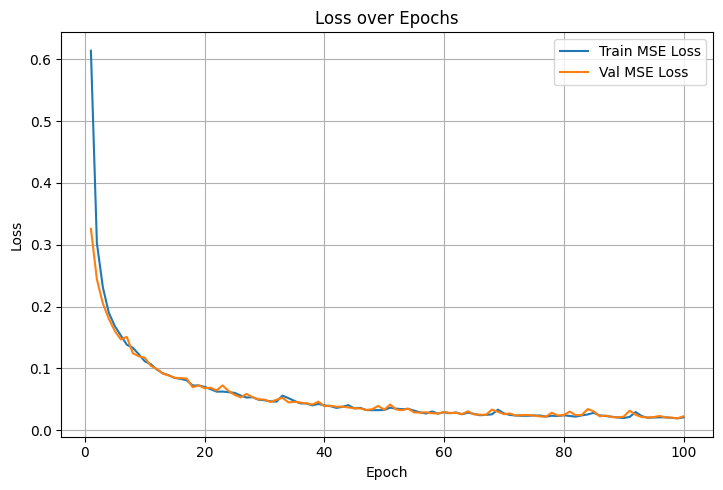

In [ ]:
plot_training_curves(loss_dict)

# Plot the normalized losses to check shape or trend of the losses

In [ ]:
## Scale the losses using MinMax Scaler to make them in uniform scale
from sklearn.preprocessing import MinMaxScaler
loss_scaler = MinMaxScaler()

losses = np.array([train_losses, val_losses, mse_losses, clust_losses, evid_losses, div_losses])
scaled_losses = loss_scaler.fit_transform(losses.T).T

In [ ]:
loss_dict_scaled={
        'Train Cross-Entropy': scaled_losses[2],
        'Val Cross-Entropy': scaled_losses[1]
    }

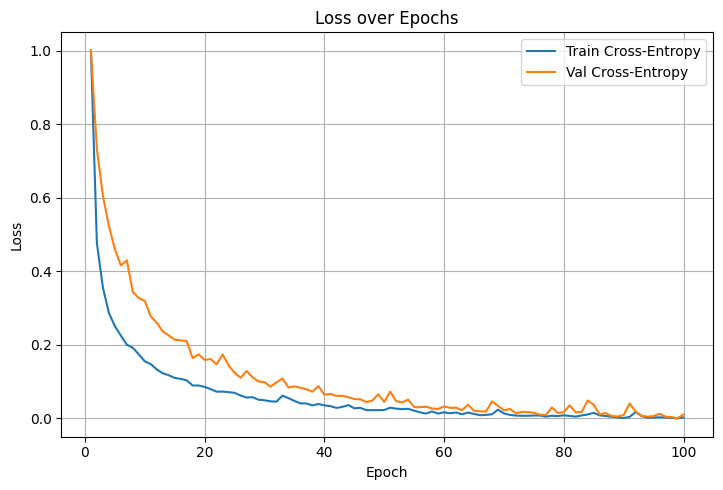

In [ ]:
plot_training_curves(loss_dict_scaled)

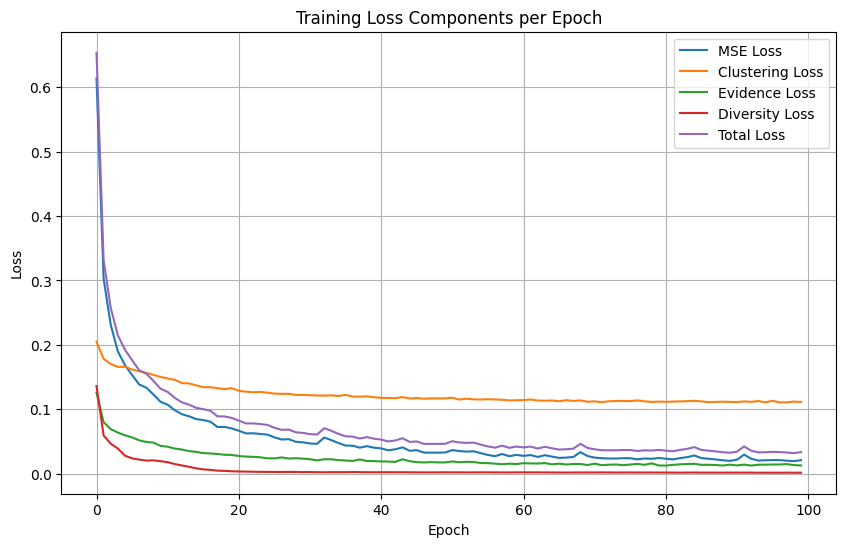

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(mse_losses, label='MSE Loss')
plt.plot(clust_losses, label='Clustering Loss')
plt.plot(evid_losses, label='Evidence Loss')
plt.plot(div_losses, label='Diversity Loss')
plt.plot(train_losses, label='Total Loss')

plt.title("Training Loss Components per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

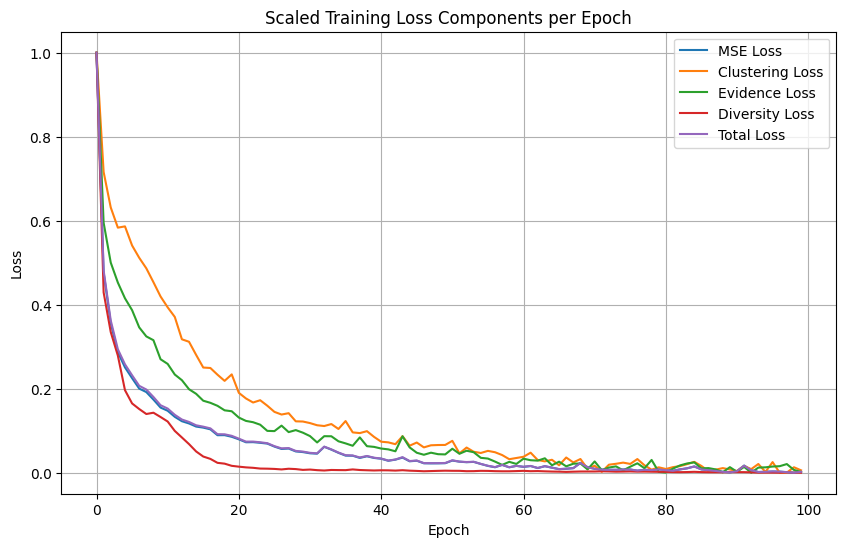

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(scaled_losses[2], label='MSE Loss')
plt.plot(scaled_losses[3], label='Clustering Loss')
plt.plot(scaled_losses[4], label='Evidence Loss')
plt.plot(scaled_losses[5], label='Diversity Loss')
plt.plot(scaled_losses[0], label='Total Loss')

plt.title("Scaled Training Loss Components per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.manifold import TSNE
def plot_prototypes_and_samples(embeddings, prototypes, method='pca'):
    """
    embeddings: np.array of shape (n_samples, n_features)
    prototypes: np.array of shape (n_prototypes, n_features)
    method: 'pca' or 'tsne'
    """
    assert method in ['pca', 'tsne'], "method must be 'pca' or 'tsne'"

    all_data = np.vstack([embeddings, prototypes])

    if method == 'pca':
        reducer = PCA(n_components=2)
    else:
        reducer = TSNE(n_components=2, perplexity=30, random_state=42)

    reduced = reducer.fit_transform(all_data)
    reduced_samples = reduced[:len(embeddings)]
    reduced_protos = reduced[len(embeddings):]

    # Plot
    plt.figure(figsize=(10, 6))


    plt.scatter(reduced_samples[:, 0], reduced_samples[:, 1], alpha=0.6, label='Samples')

    plt.scatter(reduced_protos[:, 0], reduced_protos[:, 1], color='red', s=200, edgecolors='black', marker='*', label='Prototypes')

    plt.title(f"{method.upper()} Projection of Prototypes and Samples")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
prototypes =  model.prototypes.detach().cpu()
print(prototypes.shape)
# plot_prototypes_and_samples(input_embeddings, prototypes, method='tsne')


torch.Size([5, 128])


In [ ]:
prototypes.shape

torch.Size([5, 128])

In [ ]:
projected_prototypes, prototype_targets = project_prototypes(model, train_dl)

print(f"Number of prototypes learned : {len(projected_prototypes)}")
print(projected_prototypes[0].shape)

Number of prototypes learned : 5
torch.Size([24, 6])


In [ ]:
import numpy as np
import torch

def evaluate(model, dataloader, target_scaler, device):
    """
    Evaluate a regression model on the dataloader.

    Args:
        model: PyTorch model
        dataloader: DataLoader with (inputs, targets)
        target_scaler: StandardScaler fitted on training targets
        device: 'cuda' or 'cpu'

    Returns:
        targets_all: np.array of true targets (original scale)
        preds_all: np.array of predicted targets (original scale)
    """
    model.eval()

    inputs_all_scaled = []
    inputs_all_original = []

    preds_all_scaled = []
    preds_all_original = []

    targets_all_original = []
    targets_all_scaled = []

    sims_all = []


    with torch.no_grad():
        for inputs, targets in dataloader:
            # Move to device
            inputs, targets = inputs.to(device), targets.to(device)
            # print(inputs.shape)
            # print(targets.shape)
            # Model prediction
            preds, sims, h = model(inputs)
            # print(preds.shape)

            inputs_np = inputs.detach().cpu().numpy()
            inputs_flat = inputs_np.reshape(-1, inputs_np.shape[-1])  # flatten to 2D for scaler
            inputs_inv_flat = input_scaler.inverse_transform(inputs_flat)
            inputs_inv = inputs_inv_flat.reshape(inputs_np.shape)
            inputs_all_scaled.append(inputs_np)
            inputs_all_original.append(inputs_inv)

            sims_np = sims.detach().cpu().numpy()
            sims_all.append(sims_np)

            # Convert predictions to CPU numpy and inverse scale
            preds_np = preds.detach().cpu().numpy()
            preds_all_scaled.append(preds_np)
            preds_inv = target_scaler.inverse_transform(preds_np)
            preds_all_original.append(preds_inv)

            # Convert targets to CPU numpy and inverse scale
            targets_np = targets.detach().cpu().numpy()
            targets_all_scaled.append(targets_np)
            targets_inv = target_scaler.inverse_transform(targets_np)
            targets_all_original.append(targets_inv)

    # Concatenate all batches
    inputs_all_scaled = np.concatenate(inputs_all_scaled)
    inputs_all_original = np.concatenate(inputs_all_original)

    preds_all_original = np.concatenate(preds_all_original)
    preds_all_scaled = np.concatenate(preds_all_scaled)

    targets_all_original = np.concatenate(targets_all_original)
    targets_all_scaled = np.concatenate(targets_all_scaled)

    sims_all = np.concatenate(sims_all)

    return inputs_all_scaled, inputs_all_original, targets_all_original, targets_all_scaled, preds_all_original, preds_all_scaled, sims_all


In [ ]:
inputs_all_scaled, inputs_all_original, targets_all_original, targets_all_scaled, preds_all_original, preds_all_scaled, sims_all  = evaluate(model, test_dl, target_scaler, device)

In [ ]:
print(len(inputs_all_scaled))
print(len(inputs_all_original))

print(len(targets_all_original))
print(len(targets_all_scaled))

print(len(preds_all_original))
print(len(preds_all_scaled))

print(len(sims_all))


3475
3475
3475
3475
3475
3475
3475


In [ ]:
import numpy as np

# Suppose all_similarities is [N, num_prototypes]
max_sim_idx = np.unravel_index(np.argmax(sims_all), sims_all.shape)
sample_idx, proto_idx = max_sim_idx
sim_score = sims_all[sample_idx, proto_idx]

print(f"Most similar sample index: {sample_idx}")
print(f"Closest prototype index: {proto_idx}")
print(f"Similarity score: {sim_score:.4f}")


Most similar sample index: 608
Closest prototype index: 2
Similarity score: 0.9993


In [ ]:
sample_seq_scaled = inputs_all_scaled[sample_idx]
sample_seq_original = inputs_all_original[sample_idx]

sample_pred_scaled = preds_all_scaled[sample_idx]       # shape [horizon]
sample_pred_original = preds_all_original[sample_idx]

sample_true_scaled = targets_all_scaled[sample_idx]
sample_true_original = targets_all_original[sample_idx]

proto_seq_scaled = projected_prototypes[proto_idx]
proto_seq_scaled = proto_seq_scaled.detach().cpu().numpy()
proto_true_scaled = prototype_targets[proto_idx]

proto_seq_original = input_scaler.inverse_transform(proto_seq_scaled)
proto_true_original = target_scaler.inverse_transform(proto_true_scaled.reshape(1, -1)).flatten()



print("\nScaled values of Results\n=================================================================\n")

print(f"Sample Seq : {sample_seq_scaled}")
print(f"Sample Pred: {sample_pred_scaled}")
print(f"Sample True: {sample_true_scaled}")

print(f"Proto Seq : {proto_seq_scaled}")
print(f"Proto True : {proto_true_scaled}")

print("Original values of Results\n=================================================================\n")

print(f"Sample Seq : {sample_seq_original}")
print(f"Sample Pred: {sample_pred_original}")
print(f"Sample True: {sample_true_original}")

print(f"Proto Seq : {proto_seq_original}")
print(f"Proto True : {proto_true_original}")





Scaled values of Results

Sample Seq : [[ 0.23620726  1.8573269   0.32797632  1.3430095  -0.32592493  0.7039296 ]
 [ 0.35982737  1.3332866   0.3854389   1.3430095  -0.16721651  0.7039296 ]
 [ 0.36933655  1.0382389   0.31754193  1.1073655  -0.24613702  0.5005361 ]
 [ 0.14111489  1.0054559   0.20276365  0.8524065  -0.53666914  0.29881   ]
 [ 0.07469217  1.0382389   0.1870386   0.87227345 -0.51065135  0.5005361 ]
 [ 0.06518295  1.2677205   0.20790741  1.2447785  -0.72139555  0.3488247 ]
 [ 0.0461645   1.0054559   0.22363245  1.2646455  -0.61645705  0.40050665]
 [ 0.01763676  0.9726726   0.11914163  1.1465474  -0.61645705  0.40050665]
 [ 0.15062419  0.93988955  0.19232924  0.98981947 -0.2730222   0.40050665]
 [ 0.01763676  0.80875725  0.08254778  0.8330915  -0.43086344  0.3488247 ]
 [ 0.09371069  0.54649246  0.13486667  0.63662964 -0.24613702  0.24712804]
 [ 0.09371069  0.5137094   0.15044476  0.6564966  -0.29904     0.14543138]
 [-0.03941865  0.4481432   0.05124466  0.5974476  -0.5106513

In [ ]:
proto_seq_original.shape

(24, 6)

In [ ]:
with torch.no_grad():
    proto_input = torch.tensor(proto_seq_scaled).unsqueeze(0).to(device)
    proto_pred, proto_sim, proto_h = model(proto_input)  # should output [1, horizon]
    proto_pred_np = proto_pred.detach().cpu().numpy()

    # If the model output is 1D, reshape for scaler
    if proto_pred_np.ndim == 1:
        proto_pred_np = proto_pred_np.reshape(-1, 1)

    # ✅ Use target_scaler, not input_scaler
    proto_pred_inv = target_scaler.inverse_transform(proto_pred_np)


In [ ]:
print("Proto Prediction\n", proto_pred_inv)


Proto Prediction
 [[23.830093 24.519882 25.18786  25.902218 26.370907 26.414228 26.402954
  25.95523  25.200924 24.410223 23.349804 22.328999 21.4611   20.752365
  20.366732 19.926107 19.610905 19.478443 19.199924 18.938246 18.90816
  19.108871 19.674097 20.237055]]


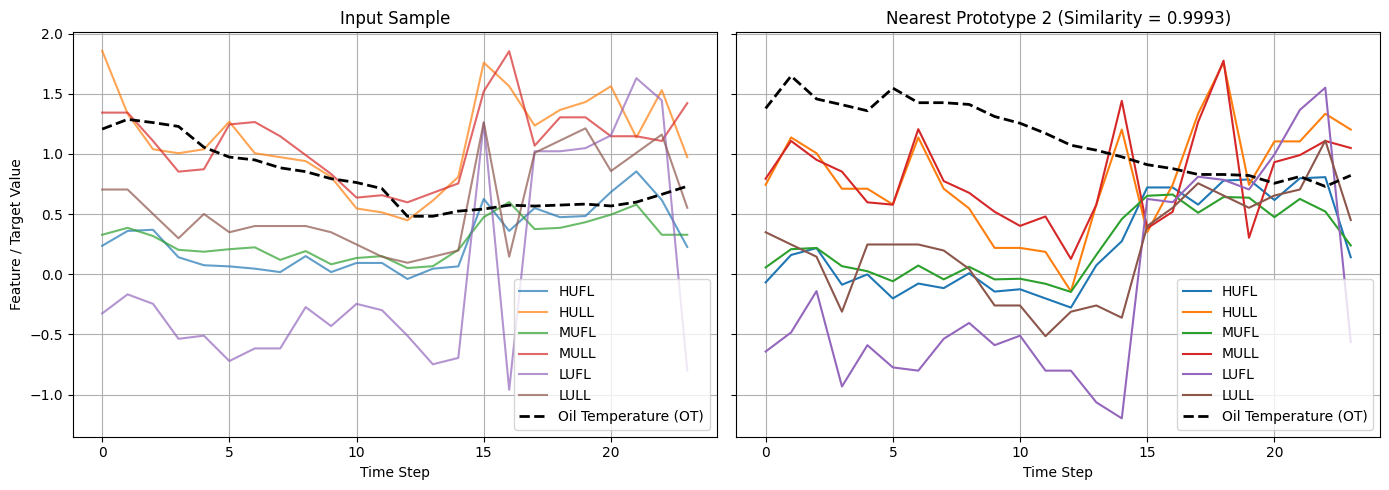

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Plot Input Sample
for feat_idx in range(sample_seq_scaled.shape[1]):
    axes[0].plot(sample_seq_scaled[:, feat_idx], label=features[feat_idx], alpha=0.7)

axes[0].plot(sample_true_scaled, label="Oil Temperature (OT)", color="black", linewidth=2, linestyle="--")
axes[0].set_title("Input Sample")
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("Feature / Target Value")
axes[0].legend()
axes[0].grid(True)


# Plot Nearest Prototype
for feat_idx in range(proto_seq_scaled.shape[1]):
    axes[1].plot(proto_seq_scaled[:, feat_idx], label=features[feat_idx], linestyle="-")

axes[1].plot(proto_true_scaled, label="Oil Temperature (OT)", color="black", linewidth=2, linestyle="--")
axes[1].set_title(f"Nearest Prototype {proto_idx} (Similarity = {sims_all[sample_idx, proto_idx]:.4f})")
axes[1].set_xlabel("Time Step")
axes[1].legend()
axes[1].grid(True)


# Final layout
plt.tight_layout()
plt.show()

Groud Truth  [23.707 24.41  24.199 23.918 22.441 21.737 21.526 20.963 20.682 20.19
 19.908 19.486 17.516 17.516 17.868 18.009 18.29  18.22  18.29  18.361
 18.22  18.501 19.064 19.627]
Sample Prediction  [22.113865 22.032263 21.765894 21.588648 21.28418  20.843609 20.695133
 20.423857 20.035547 19.828472 19.323616 18.834953 18.4183   17.863472
 17.490988 17.190657 16.983091 17.055996 17.241005 17.58756  18.071657
 18.462576 19.145126 19.447056]
Prototype Prediction  [[23.830093 24.519882 25.18786  25.902218 26.370907 26.414228 26.402954
  25.95523  25.200924 24.410223 23.349804 22.328999 21.4611   20.752365
  20.366732 19.926107 19.610905 19.478443 19.199924 18.938246 18.90816
  19.108871 19.674097 20.237055]]


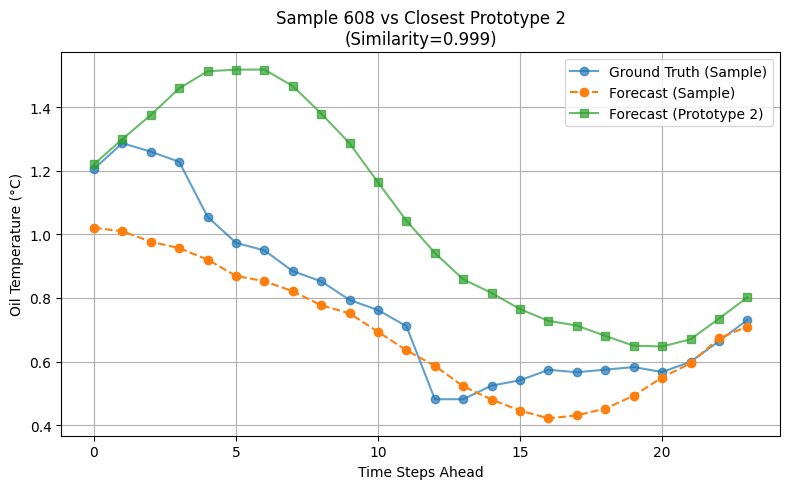

In [ ]:
import matplotlib.pyplot as plt

time_steps = np.arange(len(sample_pred_scaled))

# if hasattr(proto_pred, "detach"):
#     proto_pred = proto_pred.detach().cpu().numpy().squeeze()
# else:
#     proto_pred = np.array(proto_pred).squeeze()
# print(proto_pred.shape)


print("Groud Truth ", sample_true_original)
print("Sample Prediction ", sample_pred_original)
print("Prototype Prediction ", proto_pred_inv)

plt.figure(figsize=(8, 5))
plt.plot(time_steps, sample_true_scaled, 'o-', label="Ground Truth (Sample)", alpha=0.7)
plt.plot(time_steps, sample_pred_scaled, 'o--', label="Forecast (Sample)")
plt.plot(time_steps, proto_pred_np.squeeze(), 's-', label=f"Forecast (Prototype {proto_idx})", alpha=0.7)

plt.title(f"Sample {sample_idx} vs Closest Prototype {proto_idx}\n(Similarity={sims_all[sample_idx, proto_idx]:.3f})")
plt.xlabel("Time Steps Ahead")
plt.ylabel("Oil Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# baseline_pred = np.full_like(y_test, fill_value=np.mean(y_train), dtype=np.float32)

# mse_baseline = mean_squared_error(y_test, baseline_pred)
# rmse_baseline = np.sqrt(mse_baseline)
# mae_baseline = mean_absolute_error(y_test, baseline_pred)
# r2_baseline = r2_score(y_test, baseline_pred)

# print("Baseline Performance (Mean Predictor):")
# print(f"MSE: {mse_baseline:.4f}")
# print(f"RMSE: {rmse_baseline:.4f}")
# print(f"MAE: {mae_baseline:.4f}")
# print(f"R²: {r2_baseline:.4f}")

mse = mean_squared_error(targets_all_scaled, preds_all_scaled)
mae = mean_absolute_error(targets_all_scaled, preds_all_scaled)
rmse = np.sqrt(mse)
r2 = r2_score(targets_all_scaled, preds_all_scaled)

print("\nModel Performance Metrics):")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")


Model Performance Metrics):
MSE: 0.0229
RMSE: 0.1512
MAE: 0.1111
R²: 0.9771


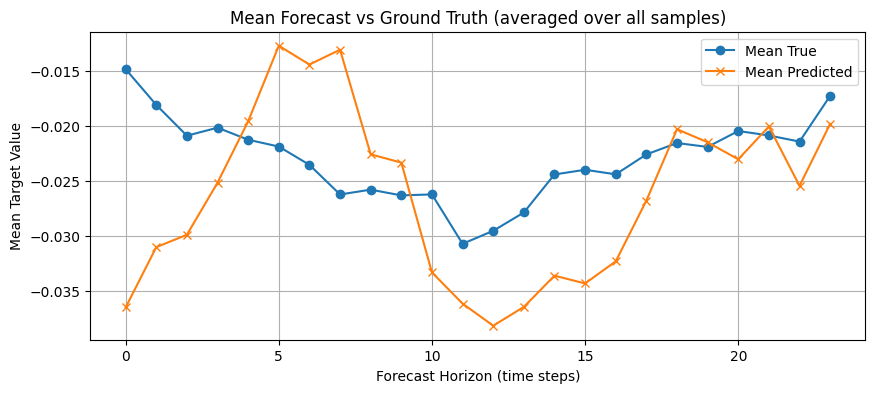

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

mean_target = np.mean(targets_all_scaled, axis=0)
mean_pred = np.mean(preds_all_scaled, axis=0)

plt.figure(figsize=(10,4))
plt.plot(mean_target, label="Mean True", marker='o')
plt.plot(mean_pred, label="Mean Predicted", marker='x')
plt.xlabel("Forecast Horizon (time steps)")
plt.ylabel("Mean Target Value")
plt.title("Mean Forecast vs Ground Truth (averaged over all samples)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import matplotlib.pyplot as plt

def plot_predictions(y_true, y_pred):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--', lw=2)  # reference line y=x
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title("Predicted vs True")
    plt.show()


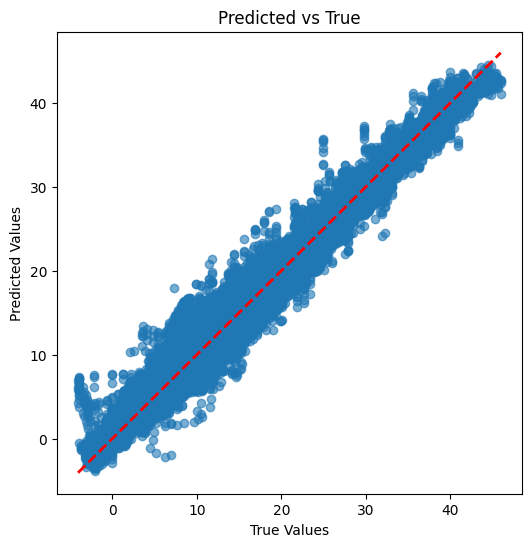

In [ ]:
plot_predictions(targets_all, preds_all)

In [ ]:
def plot_residuals(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    residuals = y_true - y_pred
    plt.figure(figsize=(6,4))
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--', lw=2)
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals (True - Pred)")
    plt.title("Residual Plot")
    plt.show()


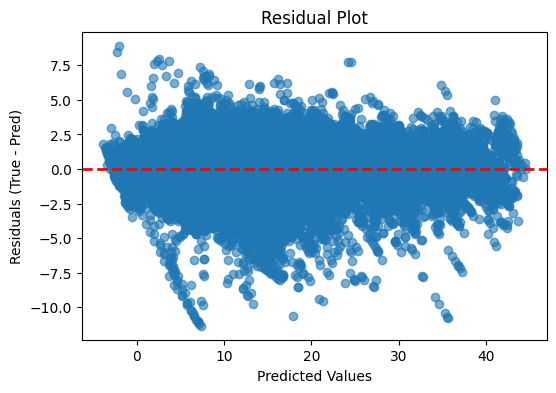

In [ ]:
plot_residuals(targets_all, preds_all)

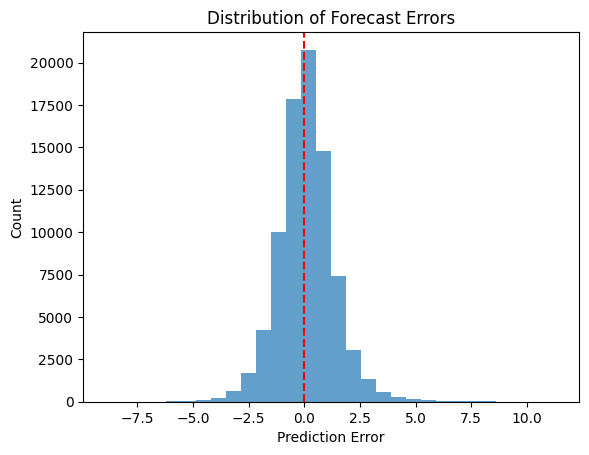

In [ ]:
errors = preds_all.flatten() - targets_all.flatten()
plt.hist(errors, bins=30, alpha=0.7)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title("Distribution of Forecast Errors")
plt.show()


In [ ]:
# projected_prototypes = project_prototypes(model, train_dl)

# print(f"Number of prototypes learned : {len(projected_prototypes)}")
# print(projected_prototypes[0].shape)

In [ ]:
# Function to check the scale of prototype features

def check_feature_scales(prototypes):
    """
    Check the min and max values of each feature across all prototypes.

    Args:
        prototypes: list of torch.Tensor of shape [seq_len, num_features]
    """
    all_data = torch.stack(prototypes)  # Shape: [num_prototypes, seq_len, num_features]
    all_data = all_data.view(-1, all_data.shape[-1])  # Shape: [num_prototypes * seq_len, num_features]

    feature_mins = all_data.min(dim=0).values
    feature_maxs = all_data.max(dim=0).values
    feature_ranges = feature_maxs - feature_mins

    for i, (min_val, max_val, rng) in enumerate(zip(feature_mins, feature_maxs, feature_ranges)):
        print(f"Feature {i}: min = {min_val:.3f}, max = {max_val:.3f}, range = {rng:.3f}")


In [ ]:
check_feature_scales(projected_prototypes)

Feature 0: min = -2.283, max = 1.111, range = 3.394
Feature 1: min = -1.617, max = 1.595, range = 3.212
Feature 2: min = -2.299, max = 0.934, range = 3.233
Feature 3: min = -1.834, max = 1.578, range = 3.412
Feature 4: min = -1.488, max = 2.237, range = 3.725
Feature 5: min = -0.515, max = 1.009, range = 1.524


In [ ]:
import math

def plot_prototypes(prototypes, feature_names):
    """
    Plot each prototype as a multivariate time series in a single window
    with 5 subplots per row.

    Args:
        prototypes: list of torch.Tensor with shape [24, 6]
        feature_names: list of strings of length 6 (names of features)
    """
    num_prototypes = len(prototypes)
    num_cols = 5
    num_rows = math.ceil(num_prototypes / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 3 * num_rows), sharex=True)
    axes = axes.flatten()

    for i, proto in enumerate(prototypes):
        sequence = proto.cpu().numpy()
        ax = axes[i]

        for feat_idx in range(sequence.shape[1]):
            ax.plot(range(sequence.shape[0]), sequence[:, feat_idx], label=feature_names[feat_idx])

        ax.set_title(f"Prototype {i}", fontsize=10)
        ax.set_xlabel("Time Step")
        ax.set_ylabel("Value")
        ax.grid(True)

        if i == 0:
            ax.legend(fontsize=8, loc='upper right')

    # Turn off any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    plt.show()


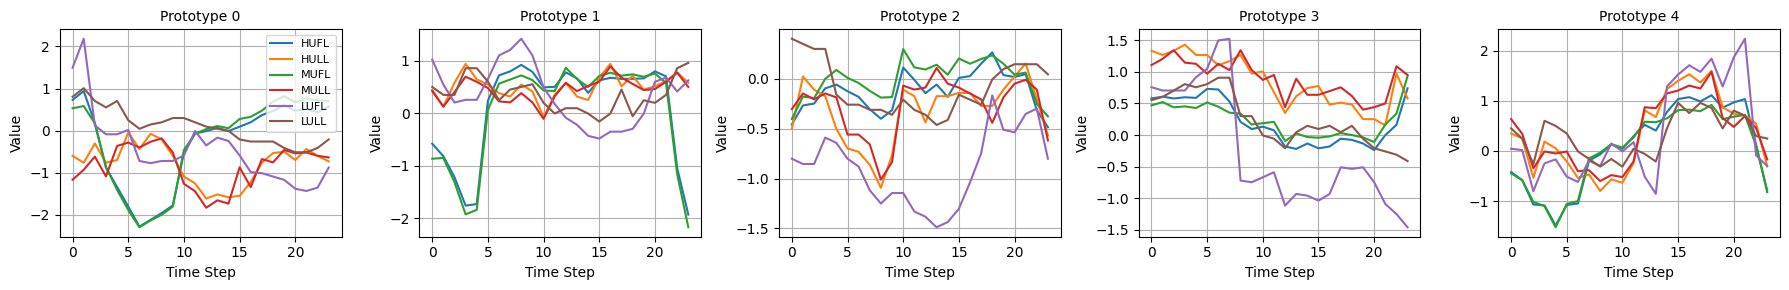

In [ ]:
plot_prototypes(projected_prototypes, features)

In [ ]:
## Normalize the features of the prototypes to plot all the features in one plot

def normalize_prototypes(prototypes):
    """
    Normalize each feature across all prototypes to [0, 1] range.

    Args:
        prototypes (list of torch.Tensor): Each tensor of shape [seq_len, num_features]

    Returns:
        tuple of torch.Tensor: Normalized tensors with same shape, one per prototype
    """

    # Stack into a tensor: [N, T, F]
    stacked = torch.stack(prototypes)

    # Flatten over time and prototypes: [N*T, F]
    flat = stacked.view(-1, stacked.shape[-1])

    # Feature-wise min/max
    min_vals = flat.min(dim=0).values
    max_vals = flat.max(dim=0).values
    ranges = max_vals - min_vals + 1e-6  # Prevent divide-by-zero

    # Normalize the stacked tensor
    norm_tensor = (stacked - min_vals) / ranges

    # Return as tuple of tensors: each [T, F]
    return tuple(norm_tensor[i] for i in range(norm_tensor.shape[0]))


In [ ]:
normalized_prototypes = normalize_prototypes(projected_prototypes)

print(f"Number of prototypes learned : {len(normalized_prototypes)}")
print(normalized_prototypes[0].shape)

Number of prototypes learned : 5
torch.Size([24, 6])


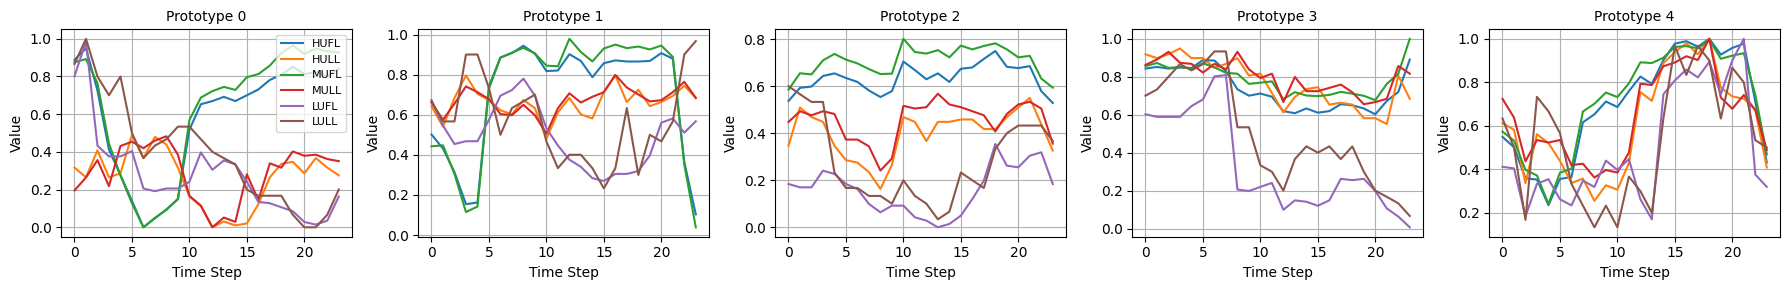

In [ ]:
plot_prototypes(normalized_prototypes, features)

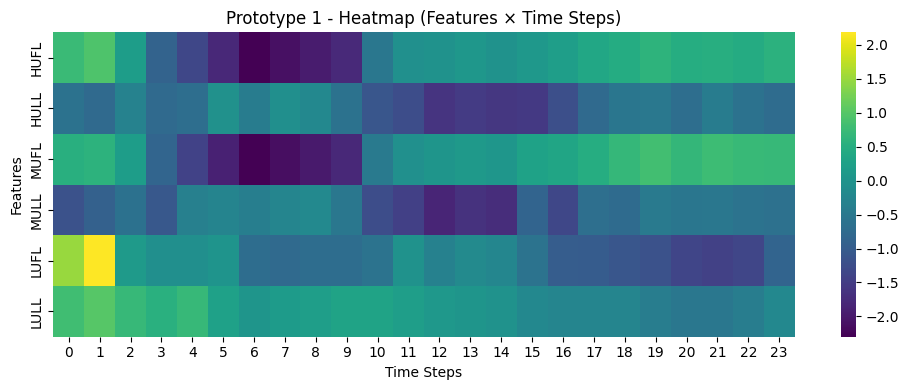

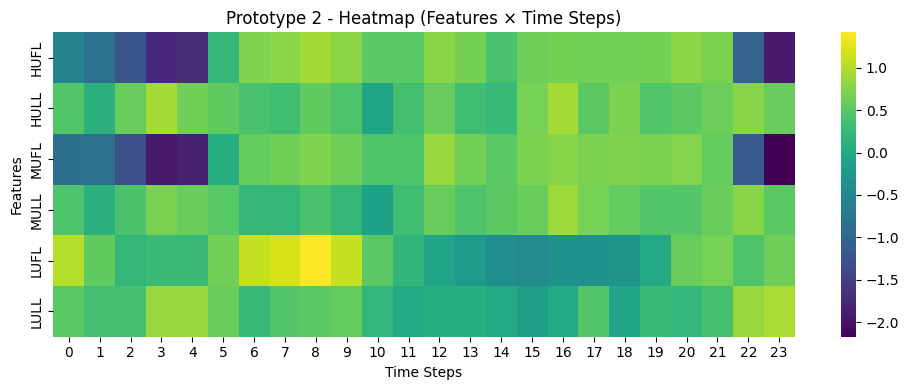

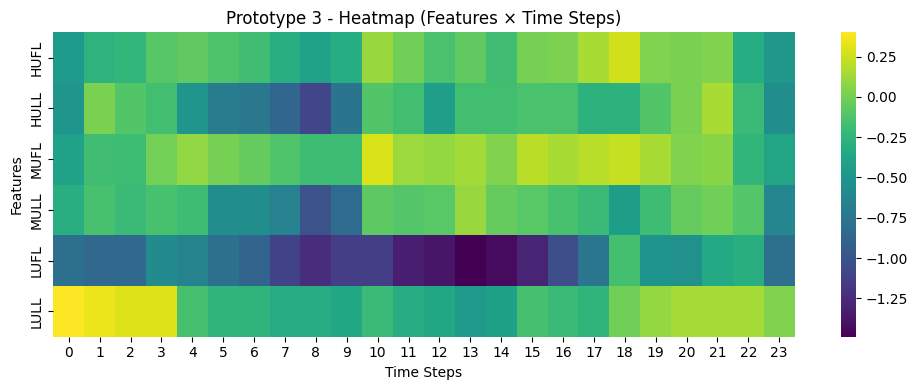

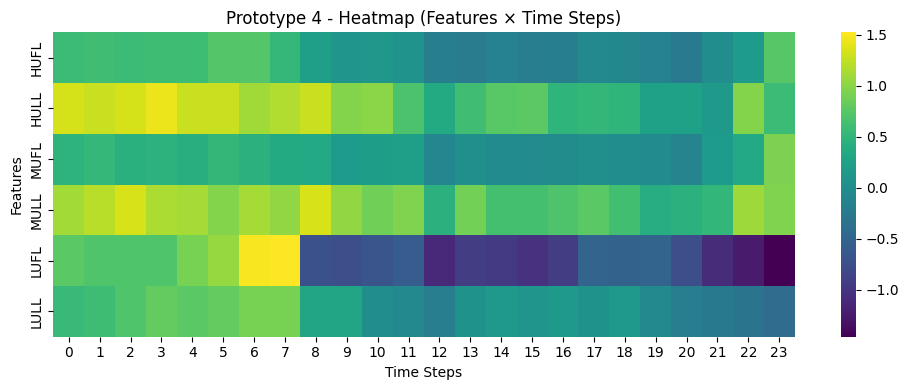

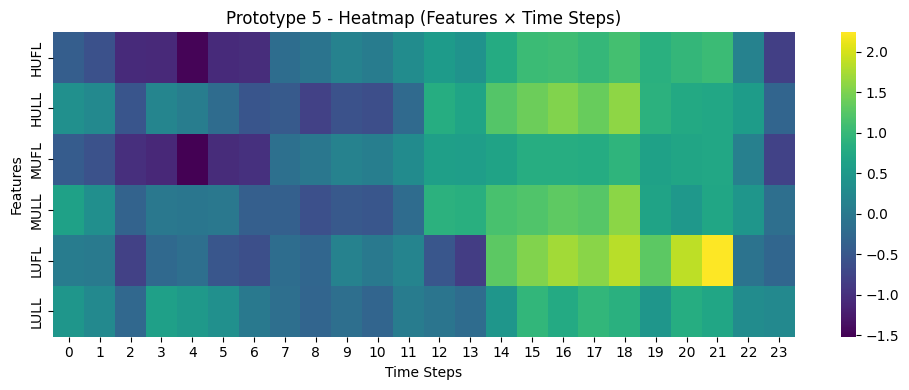

In [ ]:
import seaborn as sns

num_prototypes = len(projected_prototypes)

for i in range(num_prototypes):
    prototype = projected_prototypes[i]

    # Convert to numpy if it's a tensor
    if isinstance(prototype, torch.Tensor):
        prototype = prototype.detach().cpu().numpy()

    plt.figure(figsize=(10, 4))
    sns.heatmap(prototype.T, cmap='viridis', cbar=True,
                xticklabels=range(prototype.shape[0]),
                yticklabels=[f"{j}" for j in features])
    plt.title(f"Prototype {i+1} - Heatmap (Features × Time Steps)")
    plt.xlabel("Time Steps")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()


In [ ]:
pip install fastdtw

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp312-cp312-linux_x86_64.whl size=567860 sha256=ada190fc7e9723605b2f1e6fef53026b585af6eae21872c7e77677da12ec7576
  Stored in directory: /root/.cache/pip/wheels/ab/d0/26/b82cb0f49ae73e5e6bba4e8462fff2c9851d7bd2ec64f8891e
Successfully built fastdtw


In [ ]:
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

projected_prototypes_np = np.array([p.cpu().numpy() for p in projected_prototypes])

num_protos = projected_prototypes_np.shape[0]
dtw_matrix = np.zeros((num_protos, num_protos))

for i in range(num_protos):
    for j in range(i + 1, num_protos):
        seq_i = projected_prototypes_np[i]  # shape (timesteps, features)
        seq_j = projected_prototypes_np[j]
        dist, _ = fastdtw(seq_i, seq_j, dist=euclidean)
        dtw_matrix[i, j] = dtw_matrix[j, i] = dist


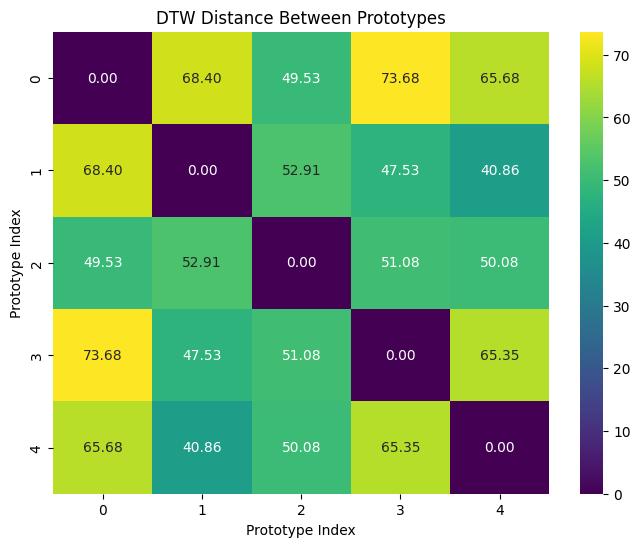

In [ ]:
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(dtw_matrix, annot=True, fmt=".2f", cmap='viridis')
plt.title("DTW Distance Between Prototypes")
plt.xlabel("Prototype Index")
plt.ylabel("Prototype Index")
plt.show()

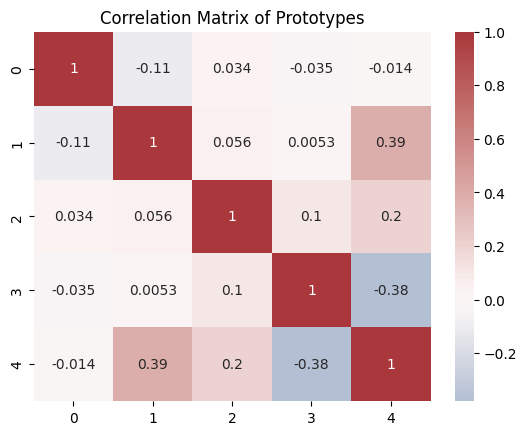

In [ ]:
# Flatten each prototype to 1D vector (timesteps * features)
num_protos = projected_prototypes_np.shape[0]
flattened_protos = projected_prototypes_np.reshape(num_protos, -1)  # shape: (num_protos, timesteps*features)

# Compute correlation matrix between prototypes
corr_matrix = np.corrcoef(flattened_protos)

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='vlag', center=0)
plt.title("Correlation Matrix of Prototypes")
plt.show()



In [ ]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from collections import defaultdict

def hierarchical_clustering_medoids(dtw_matrix, threshold):
    """
    Perform Hierarchical Clustering using DTW distance matrix
    and return medoids for each cluster.

    Args:
        dtw_matrix (np.array): Square DTW distance matrix [NxN]
        threshold (float): Distance threshold to cut dendrogram

    Returns:
        cluster_labels (np.array): Cluster assignment per prototype
        medoids (dict): {cluster_id: medoid_prototype_index}
    """
    # Convert to condensed form
    dtw_condensed = squareform(dtw_matrix)

    # Perform Hierarchical Clustering
    linkage_matrix = linkage(dtw_condensed, method='average')

    # Get Cluster Assignments
    cluster_labels = fcluster(linkage_matrix, t=threshold, criterion='distance')

    # Find Medoids in each cluster
    clusters = defaultdict(list)
    for idx, label in enumerate(cluster_labels):
        clusters[label].append(idx)

    medoids = {}
    for label, indices in clusters.items():
        min_sum_distance = float('inf')
        medoid_idx = None

        for i in indices:
            sum_distance = sum(dtw_matrix[i, j] for j in indices if i != j)
            if sum_distance < min_sum_distance:
                min_sum_distance = sum_distance
                medoid_idx = i

        medoids[label] = medoid_idx

    return cluster_labels, medoids

# --- Usage ---
threshold = 20  # You can adjust this threshold
cluster_labels, medoids = hierarchical_clustering_medoids(dtw_matrix, threshold)

print(f"Cluster Assignments: {cluster_labels}")
print(f"Cluster Medoids: {medoids}")


Cluster Assignments: [1 3 2 5 4]
Cluster Medoids: {np.int32(1): 0, np.int32(3): 1, np.int32(2): 2, np.int32(5): 3, np.int32(4): 4}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram

def plot_dendrogram_with_medoids(dtw_matrix, cluster_labels, medoids, threshold=None):
    # Convert to condensed form
    dtw_condensed = squareform(dtw_matrix)

    # Compute linkage matrix
    linkage_matrix = linkage(dtw_condensed, method='average')

    plt.figure(figsize=(12, 6))
    dendro = dendrogram(linkage_matrix, labels=[f"P{i}" for i in range(dtw_matrix.shape[0])],
                        color_threshold=threshold, above_threshold_color='gray')
    plt.title("Hierarchical Clustering Dendrogram (DTW Distance)")
    plt.xlabel("Prototypes")
    plt.ylabel("DTW Distance")

    # Highlight medoids on x-axis labels
    ax = plt.gca()
    xlbls = ax.get_xmajorticklabels()
    medoid_indices = list(medoids.values())
    for lbl in xlbls:
        proto_idx = int(lbl.get_text().replace('P', ''))
        if proto_idx in medoid_indices:
            lbl.set_color('red')
            lbl.set_fontweight('bold')

    plt.show()


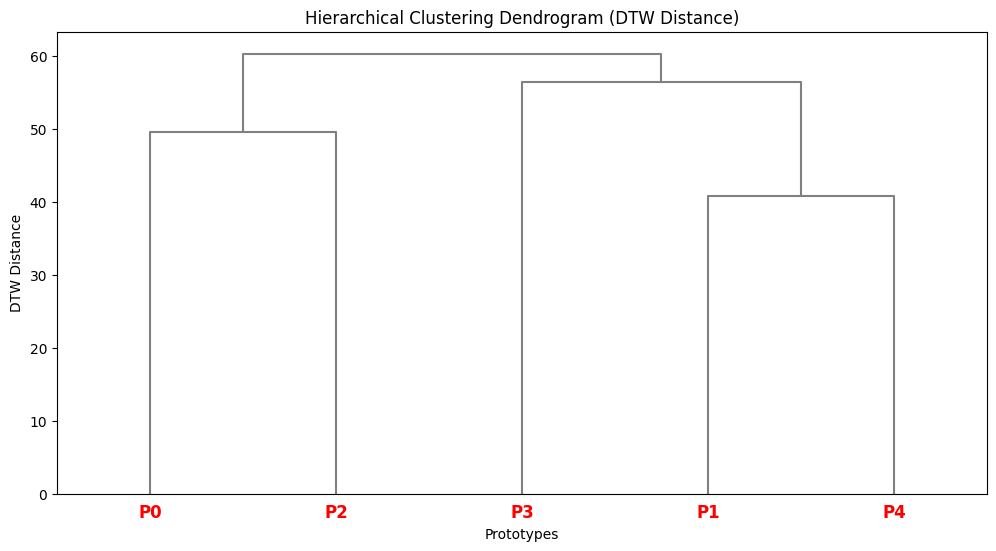

In [ ]:
threshold = 20  # Adjust based on your desired cut-off
plot_dendrogram_with_medoids(dtw_matrix, cluster_labels, medoids, threshold=threshold)

In [ ]:
from itertools import combinations

projected_prototypes = torch.stack([
p.float() if isinstance(p, torch.Tensor) else torch.tensor(p, dtype=torch.float32)
for p in projected_prototypes])

flat_prototypes = projected_prototypes.view(projected_prototypes.size(0), -1).cpu().detach().numpy()  # [10, 144]

# kmeans = KMeans(n_clusters=3, random_state=0)
# cluster_labels = kmeans.fit_predict(flat_prototypes)  # Shape: [10]
# cluster_centers = kmeans.cluster_centers_

print(f"#Prototypes: {n_prototypes} \n")

intra_distances, inter_distances = compute_intra_inter_distances(dtw_matrix, cluster_labels, medoids)

print("Intra-cluster Distances:")
for cluster_id, dist in sorted(intra_distances.items()):
    print(f"Cluster {cluster_id}: {dist:.2f}")

print("\nInter-cluster Distances between Medoids:")
for (c1, c2), dist in sorted(inter_distances.items()):
    print(f"Cluster {c1} to Cluster {c2}: {dist:.2f}")

#Prototypes: 5 

Intra-cluster Distances:
Cluster 1: 0.00
Cluster 2: 0.00
Cluster 3: 0.00
Cluster 4: 0.00
Cluster 5: 0.00

Inter-cluster Distances between Medoids:
Cluster 1 to Cluster 2: 49.53
Cluster 1 to Cluster 3: 68.40
Cluster 1 to Cluster 4: 65.68
Cluster 1 to Cluster 5: 73.68
Cluster 2 to Cluster 4: 50.08
Cluster 2 to Cluster 5: 51.08
Cluster 3 to Cluster 2: 52.91
Cluster 3 to Cluster 4: 40.86
Cluster 3 to Cluster 5: 47.53
Cluster 5 to Cluster 4: 65.35


In [ ]:
import numpy as np
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from collections import defaultdict

def prune_prototypes_by_dtw(dtw_matrix, threshold):
    """
    Prune redundant prototypes using Hierarchical Clustering on DTW distance.

    Args:
        dtw_matrix (np.array): Square DTW distance matrix [NxN]
        threshold (float): DTW distance threshold for pruning

    Returns:
        distinct_prototypes (list): Indices of distinct prototypes (medoids)
        pruned_prototypes (list): Indices of pruned (redundant) prototypes
        cluster_labels (np.array): Cluster label for each prototype
    """
    # Convert DTW matrix to condensed form
    dtw_condensed = squareform(dtw_matrix)

    # Hierarchical Clustering
    linkage_matrix = linkage(dtw_condensed, method='average')

    # Cut tree at threshold
    cluster_labels = fcluster(linkage_matrix, t=threshold, criterion='distance')

    # Find Medoids (most central prototype per cluster)
    clusters = defaultdict(list)
    for idx, label in enumerate(cluster_labels):
#         print(f"Cluster {label} members: {idx}")
        clusters[label].append(idx)

    distinct_prototypes = []
    pruned_prototypes = []



    for label, indices in clusters.items():
        print(f"Cluster {label} members: {indices}")
        print(len(indices))

        if len(indices) == 1:
            medoid_idx = indices[0]
            distinct_prototypes.append(medoid_idx)
            continue

        # For clusters with multiple members:
        min_sum_distance = float('inf')
        medoid_idx = None

        for i in indices:
            sum_distance = sum(dtw_matrix[i, j] for j in indices if i != j)
            if sum_distance < min_sum_distance:
                min_sum_distance = sum_distance
                medoid_idx = i

        distinct_prototypes.append(medoid_idx)


        # Others are pruned
        pruned = [i for i in indices if i != medoid_idx]
        pruned_prototypes.extend(pruned)

    return distinct_prototypes, pruned_prototypes, cluster_labels



In [ ]:
threshold = 20  # Set threshold based on dendrogram observation
distinct_prototypes, pruned_prototypes, cluster_labels = prune_prototypes_by_dtw(dtw_matrix, threshold)

print(f"Distinct Prototypes (Medoids): {distinct_prototypes}")
print(f"Pruned (Redundant) Prototypes: {pruned_prototypes}")

Cluster 1 members: [0]
1
Cluster 3 members: [1]
1
Cluster 2 members: [2]
1
Cluster 5 members: [3]
1
Cluster 4 members: [4]
1
Distinct Prototypes (Medoids): [0, 1, 2, 3, 4]
Pruned (Redundant) Prototypes: []


In [ ]:
model.prototypes

Parameter containing:
tensor([[-7.3287e-03, -7.2390e-03, -1.2604e-02, -2.3731e-03, -2.8326e-01,
         -7.0464e-03, -5.7808e-03, -5.0590e-03, -2.9054e-01, -4.0074e-03,
          1.6170e-03, -3.3618e-03, -2.8826e-01, -5.4824e-03, -4.3985e-03,
         -9.8029e-03, -6.1448e-03, -3.2241e-03, -5.3090e-03, -7.5793e-03,
         -3.7795e-03, -4.4181e-03, -3.2681e-03, -1.2233e-02, -7.2977e-03,
         -6.8649e-03, -8.7444e-03, -1.1362e-02, -8.8082e-03, -2.8930e-03,
         -7.2572e-03, -7.6272e-03, -7.1835e-03, -9.9365e-03, -4.6885e-03,
         -1.7367e-03, -7.7224e-03, -1.0346e-02, -4.0252e-02, -9.5357e-03,
         -6.5809e-03, -3.0352e-03, -3.2483e-03, -1.0416e-01, -2.6652e-03,
         -3.6998e-03, -3.8505e-03,  2.8734e-01, -9.4582e-03, -4.3028e-03,
         -2.9144e-01, -2.9548e-01, -5.7728e-03, -1.1662e-02, -4.9298e-03,
         -9.0402e-04, -9.2269e-03, -7.6621e-03, -1.2622e-02, -1.9292e-03,
         -5.5597e-03, -7.2375e-03, -6.2551e-03, -1.1617e-02, -3.8236e-03,
         -9.1569

In [ ]:
import torch
import torch.nn as nn

def update_prosenet_with_pruned_prototypes(model, retained_proto_indices):
    """
    Updates the ProSeNet model after prototype pruning.

    Args:
        model (nn.Module): The original ProSeNet model.
        retained_proto_indices (list): List of prototype indices to keep.

    Returns:
        model (nn.Module): The updated model with pruned prototypes and resized fc layer.
    """
    device = model.device
    retained_proto_indices = sorted(retained_proto_indices)

    # Extract pruned prototypes
    new_prototypes = model.prototypes[retained_proto_indices].detach().clone()
    model.prototypes = nn.Parameter(new_prototypes.to(device))

    # Update the fc layer input dimension
    hidden_dim = model.encoder.hidden_size * 2  # bidirectional
    new_fc_in_features = hidden_dim + len(retained_proto_indices)
    old_fc_out_features = model.fc.out_features

    # Create new fc layer with same output dimension
    model.fc = nn.Linear(new_fc_in_features, old_fc_out_features).to(device)

    print(f"Updated model: {len(retained_proto_indices)} prototypes, fc in_features={new_fc_in_features}, out_features={old_fc_out_features}")

    return model


In [ ]:
retained_proto_indices = distinct_prototypes  # The medoids you kept after pruning
updt_model = update_prosenet_with_pruned_prototypes(model, retained_proto_indices)

Updated model: 5 prototypes, fc in_features=133, out_features=24


In [ ]:
updt_model

ProSeNetRegressor(
  (encoder): LSTM(6, 64, num_layers=3, batch_first=True, dropout=0.1, bidirectional=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=133, out_features=24, bias=True)
)

In [ ]:
def count_prototype_utilization(model, dataloader, device='cpu'):
    model.eval()
    prototype_counts = torch.zeros(model.prototypes.shape[0], dtype=torch.int32)

    with torch.no_grad():
        for batch in dataloader:
            inputs, labels = batch
            inputs, labels = inputs.to(device), labels.to(device)
            _, sims, _ = model(inputs)
            assigned_proto = torch.argmax(sims, dim=1)  # Assigned prototype per sample

            for idx in assigned_proto:
                prototype_counts[idx.item()] += 1

    return prototype_counts


In [ ]:
prototype_counts = count_prototype_utilization(updt_model, train_dl)

Prototype utilization summary:
Prototype 0: assigned 2786 samples
Prototype 1: assigned 1744 samples
Prototype 2: assigned 3707 samples
Prototype 3: assigned 1342 samples
Prototype 4: assigned 1539 samples


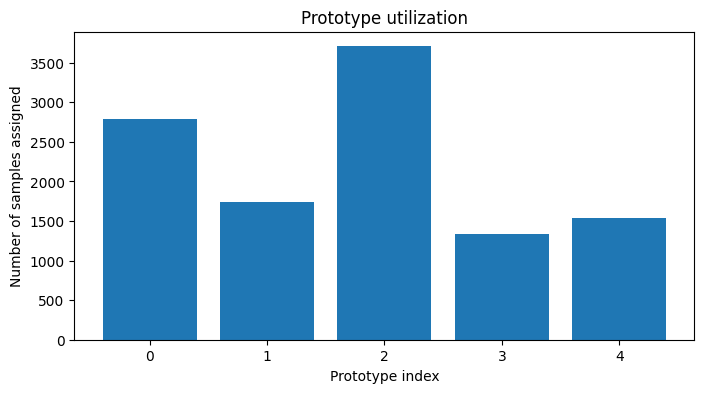

In [ ]:

print("Prototype utilization summary:")
for i, count in enumerate(prototype_counts):
    print(f"Prototype {i}: assigned {count} samples")

# Optional: visualize
plt.figure(figsize=(8, 4))
plt.bar(range(len(prototype_counts)), prototype_counts)
plt.xlabel("Prototype index")
plt.ylabel("Number of samples assigned")
plt.title("Prototype utilization")
plt.show()




In [ ]:
latest_protos = updt_model.prototypes.detach().cpu()
print(latest_protos.shape)

torch.Size([5, 128])


In [ ]:
latest_protos

tensor([[-7.3287e-03, -7.2390e-03, -1.2604e-02, -2.3731e-03, -2.8326e-01,
         -7.0464e-03, -5.7808e-03, -5.0590e-03, -2.9054e-01, -4.0074e-03,
          1.6170e-03, -3.3618e-03, -2.8826e-01, -5.4824e-03, -4.3985e-03,
         -9.8029e-03, -6.1448e-03, -3.2241e-03, -5.3090e-03, -7.5793e-03,
         -3.7795e-03, -4.4181e-03, -3.2681e-03, -1.2233e-02, -7.2977e-03,
         -6.8649e-03, -8.7444e-03, -1.1362e-02, -8.8082e-03, -2.8930e-03,
         -7.2572e-03, -7.6272e-03, -7.1835e-03, -9.9365e-03, -4.6885e-03,
         -1.7367e-03, -7.7224e-03, -1.0346e-02, -4.0252e-02, -9.5357e-03,
         -6.5809e-03, -3.0352e-03, -3.2483e-03, -1.0416e-01, -2.6652e-03,
         -3.6998e-03, -3.8505e-03,  2.8734e-01, -9.4582e-03, -4.3028e-03,
         -2.9144e-01, -2.9548e-01, -5.7728e-03, -1.1662e-02, -4.9298e-03,
         -9.0402e-04, -9.2269e-03, -7.6621e-03, -1.2622e-02, -1.9292e-03,
         -5.5597e-03, -7.2375e-03, -6.2551e-03, -1.1617e-02, -3.8236e-03,
         -9.1569e-05,  1.8750e-03,  2.

In [ ]:
latest_protos, latest_proto_targets = project_prototypes(updt_model, train_dl)
print(f"Number of prototypes learned : {len(latest_protos)}")
print(latest_protos[0].shape)


Number of prototypes learned : 5
torch.Size([24, 6])


In [ ]:
latest_protos

[tensor([[ 0.7305, -0.6004,  0.5317, -1.1674,  1.4971,  0.8056],
         [ 0.9397, -0.7643,  0.5840, -0.9318,  2.1839,  1.0090],
         [ 0.1792, -0.3054,  0.1713, -0.6183,  0.1233,  0.7039],
         [-0.8855, -0.7643, -0.8627, -1.0890, -0.0874,  0.5522],
         [-1.3418, -0.6988, -1.4110, -0.3633, -0.0874,  0.7039],
         [-1.8076, -0.0436, -1.8862, -0.2850,  0.0175,  0.2471],
         [-2.2829, -0.4365, -2.2988, -0.4025, -0.7214,  0.0437],
         [-2.1214, -0.0764, -2.1369, -0.2651, -0.7743,  0.1454],
         [-1.9597, -0.2075, -2.0011, -0.1867, -0.7214,  0.1971],
         [-1.7790, -0.6004, -1.8078, -0.5201, -0.7214,  0.2988],
         [-0.5242, -1.0922, -0.4605, -1.2651, -0.5896,  0.2988],
         [-0.0679, -1.2561, -0.0741, -1.4417, -0.0085,  0.1971],
         [-0.0109, -1.6167,  0.0355, -1.8340, -0.3519,  0.0954],
         [ 0.0652, -1.5184,  0.1087, -1.6574, -0.1672,  0.0437],
         [-0.0109, -1.5839,  0.0565, -1.7358, -0.2461, -0.0063],
         [ 0.0937, -1.551

In [ ]:
import numpy as np
from scipy.fft import rfft

def analyze_feature_shape(signal, freq_threshold=0.1, step_threshold=0.3, flat_threshold=0.05):
    """
    Classifies a 1D time series signal based on shape and frequency properties.

    Parameters:
        signal (np.ndarray): 1D array of time series values (e.g., one feature from a prototype).
        freq_threshold (float): threshold ratio for detecting high-frequency content.
        step_threshold (float): threshold for detecting a sudden step change.
        flat_threshold (float): threshold for detecting flat signal variation.

    Returns:
        str: one of ["flat", "step", "oscillating", "trending"]
    """
    signal = np.asarray(signal)
    diffs = np.diff(signal)
    max_jump = np.max(np.abs(diffs))
    total_variation = np.sum(np.abs(diffs))

    # 1. Check flatness
    if np.std(signal) < flat_threshold:
        return "flat"

    # 2. Check for step change
    if max_jump > step_threshold:
        return "step"

    # 3. Check oscillation using FFT
    fft_vals = np.abs(rfft(signal - np.mean(signal)))
    if len(fft_vals) < 2:
        return "flat"  # Not enough signal to analyze
    dominant_freq_ratio = np.max(fft_vals[1:]) / (np.sum(fft_vals[1:]) + 1e-8)
    if dominant_freq_ratio > freq_threshold:
        return "oscillating"

    # 4. Otherwise, it's a trend
    return "trending"


In [ ]:
def analyze_prototypes_shape(prototypes, features,
                              freq_threshold=0.1, step_threshold=0.5, flat_threshold=0.05):
    """
    Applies shape classification to each feature in each prototype.

    Parameters:
        prototypes (np.ndarray): shape (num_prototypes, seq_len, num_features)
        feature_names (list of str): names of each feature (length = num_features)
        freq_threshold (float): threshold for oscillation detection
        step_threshold (float): threshold for step change detection
        flat_threshold (float): threshold for flat signal detection

    Returns:
        dict: Nested dictionary with structure:
              {prototype_index: {feature_name: shape_label}}
    """
    results = {}
    projected_prototypes_tensor = torch.stack(prototypes)
    prototypes = projected_prototypes_tensor.cpu().detach().numpy()
#     prototypes = prototypes.detach().cpu().numpy()
    for p_idx, proto in enumerate(prototypes):
        feature_shapes = {}
        for f_idx, fname in enumerate(features):
            shape_label = analyze_feature_shape(proto[:, f_idx],
                                                freq_threshold=freq_threshold,
                                                step_threshold=step_threshold,
                                                flat_threshold=flat_threshold)
            feature_shapes[fname] = shape_label
        results[p_idx] = feature_shapes
    return results


In [ ]:
analyze_prototypes_shape(latest_protos, features)

{0: {'HUFL': 'step',
  'HULL': 'step',
  'MUFL': 'step',
  'MULL': 'step',
  'LUFL': 'step',
  'LULL': 'oscillating'},
 1: {'HUFL': 'step',
  'HULL': 'oscillating',
  'MUFL': 'step',
  'MULL': 'oscillating',
  'LUFL': 'step',
  'LULL': 'step'},
 2: {'HUFL': 'oscillating',
  'HULL': 'step',
  'MUFL': 'oscillating',
  'MULL': 'step',
  'LUFL': 'step',
  'LULL': 'oscillating'},
 3: {'HUFL': 'step',
  'HULL': 'step',
  'MUFL': 'step',
  'MULL': 'step',
  'LUFL': 'step',
  'LULL': 'step'},
 4: {'HUFL': 'step',
  'HULL': 'step',
  'MUFL': 'step',
  'MULL': 'step',
  'LUFL': 'step',
  'LULL': 'step'}}

In [ ]:
num_sequences = len(test_dl.dataset)
print(num_sequences)

3475


# Text Generation for a particular prediction

In [1]:
!pip install transformers accelerate torch

In [2]:
!pip install --upgrade transformers huggingface_hub accelerate


In [2]:
!pip install -U langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.9/469.9 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 1.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.79
    Uninstalling langchain-core-0.3.79:
      Successfully uninstalled langchain-core-0.3.79
  Attempting uninstall: langchain-text-splitters
    Found existing installation: langchain-text-splitters 0.3.11
    Uninstalling langchain-text-splitters-0.3.11:
      Successfully uninstalled langchain-text-splitters-0.3.11
ERROR: pip's dependency resolver

In [23]:
import numpy as np

closest_proto_idx = 2
sample_index = 608
similarity_score = 0.9993

# Sample sequence (24 × 6)
sample_seq = np.array([
    [9.042, 6.028, 6.538, 3.305, 2.68, 1.279],
    [9.913, 4.957, 6.929, 3.305, 2.863, 1.279],
    [9.98, 4.354, 6.467, 2.878, 2.772, 1.157],
    [8.372, 4.287, 5.686, 2.416, 2.437, 1.036],
    [7.904, 4.354, 5.579, 2.452, 2.467, 1.157],
    [7.837, 4.823, 5.721, 3.128, 2.224, 1.066],
    [7.703, 4.287, 5.828, 3.163, 2.345, 1.097],
    [7.502, 4.22, 5.117, 2.949, 2.345, 1.097],
    [8.439, 4.153, 5.615, 2.665, 2.741, 1.097],
    [7.502, 3.885, 4.868, 2.381, 2.559, 1.066],
    [8.038, 3.349, 5.224, 2.025, 2.772, 1.005],
    [8.038, 3.282, 5.33, 2.061, 2.711, 0.944],
    [7.1, 3.148, 4.655, 1.954, 2.467, 0.914],
    [7.703, 3.483, 4.762, 2.097, 2.193, 0.944],
    [7.837, 3.885, 5.686, 2.239, 2.254, 0.975],
    [11.788, 5.827, 7.533, 3.625, 4.508, 1.614],
    [9.913, 5.425, 8.386, 4.229, 1.949, 0.944],
    [11.253, 4.756, 6.858, 2.807, 4.234, 1.462],
    [10.717, 5.023, 6.929, 3.234, 4.234, 1.523],
    [10.784, 5.157, 7.249, 3.234, 4.264, 1.584],
    [12.19, 5.425, 7.676, 2.949, 4.386, 1.371],
    [13.396, 4.555, 8.244, 2.949, 4.934, 1.462],
    [11.721, 5.358, 6.538, 2.878, 4.721, 1.553],
    [8.975, 4.22, 6.538, 3.447, 2.132, 1.188],
])

# Prototype sequence (24 × 6)
nearest_proto = np.array([
    [6.899, 3.751, 4.691, 2.31, 2.315, 1.066],
    [8.506, 4.555, 5.721, 2.878, 2.498, 1.005],
    [8.908, 4.287, 5.792, 2.594, 2.894, 0.944],
    [6.765, 3.684, 4.762, 2.416, 1.98, 0.67],
    [7.368, 3.684, 4.477, 1.954, 2.376, 1.005],
    [5.961, 3.416, 3.909, 1.919, 2.163, 1.005],
    [6.832, 4.555, 4.797, 3.056, 2.132, 1.005],
    [6.564, 3.684, 4.015, 2.274, 2.437, 0.975],
    [7.435, 3.349, 4.726, 2.097, 2.589, 0.883],
    [6.363, 2.679, 4.015, 1.812, 2.376, 0.701],
    [6.497, 2.679, 4.051, 1.599, 2.467, 0.701],
    [5.961, 2.612, 3.767, 1.741, 2.132, 0.548],
    [5.425, 1.942, 3.305, 1.102, 2.132, 0.67],
    [7.904, 3.416, 5.401, 1.919, 1.828, 0.701],
    [9.31, 4.689, 7.427, 3.482, 1.675, 0.64],
    [12.458, 2.947, 8.742, 1.564, 3.777, 1.097],
    [12.458, 3.751, 8.813, 1.812, 3.746, 1.188],
    [11.454, 4.957, 7.782, 3.163, 3.99, 1.31],
    [12.86, 5.827, 8.671, 4.087, 3.96, 1.249],
    [12.927, 3.751, 8.635, 1.421, 3.868, 1.188],
    [11.721, 4.488, 7.533, 2.559, 4.203, 1.249],
    [12.994, 4.488, 8.564, 2.665, 4.63, 1.279],
    [13.061, 4.957, 7.853, 2.878, 4.843, 1.523],
    [8.372, 4.689, 5.934, 2.772, 2.406, 1.127],
])

forecast = np.array([
    22.113865, 22.032263, 21.765894, 21.588648, 21.28418, 20.843609, 20.695133,
    20.423857, 20.035547, 19.828472, 19.323616, 18.834953, 18.4183, 17.863472,
    17.490988, 17.190657, 16.983091, 17.055996, 17.241005, 17.58756, 18.071657,
    18.462576, 19.145126, 19.447056
])

proto_prediction = np.array([
    [23.830093, 24.519882, 25.18786, 25.902218, 26.370907, 26.414228, 26.402954,
     25.95523, 25.200924, 24.410223, 23.349804, 22.328999, 21.4611, 20.752365,
     20.366732, 19.926107, 19.610905, 19.478443, 19.199924, 18.938246,
     18.90816, 19.108871, 19.674097, 20.237055]
])

sample_true = np.array([
    23.707, 24.41, 24.199, 23.918, 22.441, 21.737, 21.526, 20.963,
    20.682, 20.19, 19.908, 19.486, 17.516, 17.516, 17.868, 18.009,
    18.29, 18.22, 18.29, 18.361, 18.22, 18.501, 19.064, 19.627
])

proto_true =  np.array([25.18400017, 27.50600073, 25.88800055, 25.46599934, 25.04400109, 26.66200031,
 25.60600048, 25.60600057, 25.46599967, 24.62100015, 24.12899923, 23.42600024,
 22.58099951, 22.22999985, 21.73699927, 21.17399958, 20.89299985, 20.47100053,
 20.47100072, 20.40099884, 19.83799942, 20.33000013, 19.62700106, 20.40099888])

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
with open("/content/drive/My Drive/documents/data_summary.txt", 'w') as f:
    f.write("""The ETT dataset contains time series data from electricity transformers.
It includes the target variable 'OT' (Oil Temperature) and 6 features:
HUFL, HULL, MUFL, MULL, LUFL, LULL — each representing power load patterns at different levels.
OT exhibits seasonal trends and local continuity, while load features show daily and weekly periodic patterns.""")

with open("/content/drive/My Drive/documents/model_summary.txt", 'w') as f:
    f.write("""Prosenet model is a sequence to perform time series Forecasting. It consist of 3 layers : encoder, prototypes and
output layer. Encoder is deep learning model such as LSTM or GRU. Prototype layer learns the prototypes which are exemplar cases in
the problem domain. Output layer return the Oil temperature for the next 5 time steps of the new input sequence with its  similarities with each representative
sequences are measured in the learned latent space. Then, the prediction of the new instance can be derived and explained by its
similar prototype sequences.""")

with open("/content/drive/My Drive/documents/prototype_summary.txt", 'w') as f:
    f.write("""Prototypes are the exemplar or representative sequences in the problem domain which are not necessarily exist in the
training data. We leverage the concept of prototype learning to construct deep sequence model with built-in interpretability.
Prototype learning is a form of case-based reasoning, which draws conclusions for new inputs by comparing them with a few exemplar
cases(ie, prototypes) in the problem domain.""")


In [ ]:
summary_dict = analyze_prototypes_shape(
    prototypes=latest_protos,
    features=features
)

print(summary_dict)

{0: {'HUFL': 'step', 'HULL': 'step', 'MUFL': 'step', 'MULL': 'step', 'LUFL': 'step', 'LULL': 'oscillating'}, 1: {'HUFL': 'step', 'HULL': 'oscillating', 'MUFL': 'step', 'MULL': 'oscillating', 'LUFL': 'step', 'LULL': 'step'}, 2: {'HUFL': 'oscillating', 'HULL': 'step', 'MUFL': 'oscillating', 'MULL': 'step', 'LUFL': 'step', 'LULL': 'oscillating'}, 3: {'HUFL': 'step', 'HULL': 'step', 'MUFL': 'step', 'MULL': 'step', 'LUFL': 'step', 'LULL': 'step'}, 4: {'HUFL': 'step', 'HULL': 'step', 'MUFL': 'step', 'MULL': 'step', 'LUFL': 'step', 'LULL': 'step'}}


In [8]:
summary_dict = {
    0: {'HUFL': 'step', 'HULL': 'step', 'MUFL': 'step', 'MULL': 'step', 'LUFL': 'step', 'LULL': 'oscillating'},
    1: {'HUFL': 'step', 'HULL': 'oscillating', 'MUFL': 'step', 'MULL': 'oscillating', 'LUFL': 'step', 'LULL': 'step'},
    2: {'HUFL': 'oscillating', 'HULL': 'step', 'MUFL': 'oscillating', 'MULL': 'step', 'LUFL': 'step', 'LULL': 'oscillating'},
    3: {'HUFL': 'step', 'HULL': 'step', 'MUFL': 'step', 'MULL': 'step', 'LUFL': 'step', 'LULL': 'step'},
    4: {'HUFL': 'step', 'HULL': 'step', 'MUFL': 'step', 'MULL': 'step', 'LUFL': 'step', 'LULL': 'step'}
}

In [26]:
import numpy as np

def detect_abnormal_condition(values, threshold_drop=0.15, threshold_rise=0.15):
    """
    Simple heuristic: detect if the series has a large sudden drop or rise.
    """
    arr = np.array(values)
    diff = np.diff(arr)
    drop_ratio = np.abs(np.min(diff)) / np.mean(arr)
    rise_ratio = np.abs(np.max(diff)) / np.mean(arr)
    if drop_ratio > threshold_drop:
        return "drop"
    elif rise_ratio > threshold_rise:
        return "rise"
    else:
        return "normal"


def generate_explanation(sample_id, similarity_score, sample_true, sample_pred, proto_true, proto_pred, summary_dict, prototype_idx):
    """
    Generate interpretive explanation comparing sample and prototype behavior,
    including abnormal condition detection.
    """

    # Detect abnormal patterns
    sample_condition = detect_abnormal_condition(sample_pred)
    proto_condition = detect_abnormal_condition(proto_pred)

    explanation = f"🧠 Explanation for Sample {sample_id}\n\n"
    explanation += (
        f"The sample sequence is found to be closely similar to **Prototype {prototype_idx}**, "
        f"with a similarity score of **{similarity_score:.3f}**. "
        f"This suggests that the model recognized a strong resemblance in overall temporal behavior.\n\n"
    )

    # Feature pattern description
    explanation += (
        "Across the transformer load features (HUFL, HULL, MUFL, MULL, LUFL, LULL), "
        "the sample and prototype display highly aligned variations — both show steady operating regions "
        "followed by mild fluctuations. This alignment across multiple features strengthens the model’s confidence "
        "in choosing this prototype as the most representative pattern.\n\n"
    )

    # Forecast comparison
    explanation += (
        f"In terms of forecasting trajectory, the **sample prediction** trends from around {sample_true[0]:.2f}°C "
        f"down to {min(sample_true):.2f}°C and then rises again to about {sample_pred[-1]:.2f}°C. "
        f"The **prototype prediction** follows a comparable path, decreasing from {max(proto_true):.2f}°C "
        f"to {min(proto_true):.2f}°C before gradually recovering. "
        "This indicates that both exhibit similar temporal evolution in oil temperature.\n\n"
    )

    # Abnormal condition analysis
    if sample_condition != "normal":
        explanation += (
            f"The sample forecast shows an **abnormal {sample_condition}** in temperature values, "
            f"which might indicate a sudden operational change or cooling/heating phase. "
        )
        if proto_condition == sample_condition:
            explanation += (
                f"Interestingly, Prototype {prototype_idx} also exhibits a similar {proto_condition} pattern, "
                "suggesting that this prototype captures comparable unusual behavior observed in the past. "
                "Thus, the model used this prototype as a reference for understanding the current deviation.\n\n"
            )
        else:
            explanation += (
                f"However, Prototype {prototype_idx} shows a relatively **{proto_condition}** pattern, "
                "meaning the sample’s anomaly is not fully mirrored in the prototype. "
                "This could suggest a potential new or intensified condition.\n\n"
            )
    else:
        explanation += (
            "The sample forecast shows no sharp temperature spikes or drops, "
            "indicating a **stable operational pattern** consistent with the prototype’s behavior.\n\n"
        )

    # Add prototype summary
    summary = summary_dict.get(prototype_idx, {})
    if summary:
        explanation += "Prototype characteristic summary:\n"
        for feature, pattern in summary.items():
            explanation += f" - {feature}: {pattern} trend\n"
        explanation += "\n"

    # Final insight
    explanation += (
        f"In conclusion, Sample {sample_id} and Prototype {prototype_idx} share similar feature evolution and "
        f"forecasting behavior. The prototype helps explain the observed oil temperature trajectory, "
        "providing useful context on whether the temperature changes stem from normal fluctuations or potential anomalies.\n"
    )

    return explanation


In [28]:
# Generate a structured numeric explanation
numeric_explanation = generate_explanation(
    sample_id=sample_index,
    similarity_score=similarity_score,
    sample_true=sample_true,
    sample_pred=forecast,
    proto_true=proto_true,
    proto_pred=proto_prediction,
    summary_dict=summary_dict,
    prototype_idx=closest_proto_idx
)

print("🧾 Numeric/Structured Explanation:\n")
print(numeric_explanation)

🧾 Numeric/Structured Explanation:

🧠 Explanation for Sample 608

The sample sequence is found to be closely similar to **Prototype 2**, with a similarity score of **0.999**. This suggests that the model recognized a strong resemblance in overall temporal behavior.

Across the transformer load features (HUFL, HULL, MUFL, MULL, LUFL, LULL), the sample and prototype display highly aligned variations — both show steady operating regions followed by mild fluctuations. This alignment across multiple features strengthens the model’s confidence in choosing this prototype as the most representative pattern.

In terms of forecasting trajectory, the **sample prediction** trends from around 23.71°C down to 17.52°C and then rises again to about 19.45°C. The **prototype prediction** follows a comparable path, decreasing from 27.51°C to 19.63°C before gradually recovering. This indicates that both exhibit similar temporal evolution in oil temperature.

The sample forecast shows no sharp temperature s

In [9]:
def build_iteration_summary_text(summary_dict):
    text = "Prototype Feature Pattern Summary:\n\n"
    for proto_id, features in summary_dict.items():
        text += f"Prototype {proto_id}:\n"
        for feature, pattern in features.items():
            text += f"  - {feature}: {pattern}\n"
        text += "\n"
    return text

iteration_summary_text = build_iteration_summary_text(summary_dict)


In [10]:
with open("/content/drive/My Drive/documents/iteration_summary.txt", "w") as f:
    f.write(iteration_summary_text)


In [11]:
from langchain.document_loaders import TextLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_paths = [
    "/content/drive/My Drive/documents/data_summary.txt",
    "/content/drive/My Drive/documents/model_summary.txt",
    "/content/drive/My Drive/documents/prototype_summary.txt",
    "/content/drive/My Drive/documents/iteration_summary.txt",
]

docs = [TextLoader(p).load() for p in text_paths]
docs_list = [doc for sub in docs for doc in sub]

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
documents = text_splitter.split_documents(docs_list)


In [12]:
documents

[Document(metadata={'source': '/content/drive/My Drive/documents/data_summary.txt'}, page_content="The ETT dataset contains time series data from electricity transformers.\nIt includes the target variable 'OT' (Oil Temperature) and 6 features:\nHUFL, HULL, MUFL, MULL, LUFL, LULL — each representing power load patterns at different levels.\nOT exhibits seasonal trends and local continuity, while load features show daily and weekly periodic patterns."),
 Document(metadata={'source': '/content/drive/My Drive/documents/model_summary.txt'}, page_content='Prosenet model is a sequence to perform time series Forecasting. It consist of 3 layers : encoder, prototypes and\noutput layer. Encoder is deep learning model such as LSTM or GRU. Prototype layer learns the prototypes which are exemplar cases in\nthe problem domain. Output layer return the Oil temperature for the next 5 time steps of the new input sequence with its  similarities with each representative'),
 Document(metadata={'source': '/c

In [13]:
!pip install chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 4.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.8/20.8 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.0/208.0 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 12.0 MB/s et

In [14]:
from langchain.vectorstores import Chroma
from langchain.embeddings import HuggingFaceEmbeddings  # optional if using local

embedding = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embedding,
    persist_directory="./chroma_rag_ett"
)

vectorstore.persist()

/tmp/ipython-input-101649715.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/tmp/ipython-input-101649715.py:12: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vectorstore.persist()


In [15]:
retriever = vectorstore.as_retriever(search_type="similarity", k=3)

In [16]:
retriever

VectorStoreRetriever(tags=['Chroma', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x7e7f89053cb0>, search_kwargs={})

In [17]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch

llm_model_name = "HuggingFaceTB/SmolLM2-1.7B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(llm_model_name)
llm_model = AutoModelForCausalLM.from_pretrained(
    llm_model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

# tokenizer = AutoTokenizer.from_pretrained(llm_model_name, force_download=True)
# llm_model = AutoModelForCausalLM.from_pretrained(llm_model_name, force_download=True)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/908 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.42G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [18]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model=llm_model,
    tokenizer=tokenizer,
    torch_dtype=torch.float16,
    device_map="auto"
)


`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cuda:0


In [19]:
import numpy as np

# Compute summary stats
sample_mean = np.mean(sample_seq, axis=0)
proto_mean  = np.mean(nearest_proto, axis=0)

sample_mean_str = ", ".join([f"{v:.2f}" for v in sample_mean])
proto_mean_str  = ", ".join([f"{v:.2f}" for v in proto_mean])

forecast_mean = np.mean(forecast)
proto_forecast_mean = np.mean(proto_prediction)


In [29]:
# query the retriever
# query = (
#     f"Explain the ProSeNet model's forecast for transformer oil temperature over 24 time steps. "
#     f"The model predicted mean value {forecast_mean:.2f}, "
#     f"based on an input sequence with mean feature values [{sample_mean_str}] "
#     f"and the closest prototype (index {closest_proto_idx}) with mean features [{proto_mean_str}] "
#     f"and similarity score {similarity_score:.4f}. "
#     f"The prototype's own forecast averaged {proto_forecast_mean:.2f}. "
#     f"Describe briefly how similarity between input and prototype features led to the predicted trend."
# )


query = (
    f"Explain the forecasting behavior of this transformer oil temperature prediction. "
    f"Below is a detailed structured analysis. "
    f"Write a short, non-technical paragraph summarizing it in plain English.\n\n"
    f"{numeric_explanation}"
)


#query = "Why did the model match this input with prototype X?"
retrieved_docs = retriever.invoke(query)

# Join retrieved context into a string
retrieved_context = "\n".join([doc.page_content for doc in retrieved_docs])


In [25]:
old_prompt_v1 = f"""
### Task
You are an expert in explainable AI for time-series forecasting.
A prototype-based model (ProSeNet) predicted future transformer oil temperature using learned prototype patterns.

### Context
{retrieved_context}

### Input–Prototype Summary
- Most similar sample index: {sample_index}
- Closest prototype index: {closest_proto_idx}
- Similarity score: {similarity_score:.4f}
- Sample forecast (mean): {forecast_mean:.2f}
- Prototype forecast (mean): {proto_forecast_mean:.2f}

### Feature Comparison (mean values)
| Feature | Sample | Prototype |
|----------|---------|-----------|
| HUFL | {sample_mean[0]:.2f} | {proto_mean[0]:.2f} |
| HULL | {sample_mean[1]:.2f} | {proto_mean[1]:.2f} |
| MUFL | {sample_mean[2]:.2f} | {proto_mean[2]:.2f} |
| MULL | {sample_mean[3]:.2f} | {proto_mean[3]:.2f} |
| LUFL | {sample_mean[4]:.2f} | {proto_mean[4]:.2f} |
| LULL | {sample_mean[5]:.2f} | {proto_mean[5]:.2f} |

### Instruction
Write a concise, **feature-based explanation** of the forecast.
- Describe how each feature (HUFL, HULL, MUFL, MULL, LUFL, LULL) compares between sample and prototype.
- Explain how these similarities influenced the forecast pattern.
- Mention the similarity score and highlight whether it indicates strong alignment.
- Comment briefly on how the prototype’s prediction trend compares with the sample’s.

Write 4-6 clear sentences suitable for a technical report.

### Answer:
"""


In [24]:
old_prompt_v2 = f"""
### Task:
You are an expert in explaining time series forecasts to non-technical users.

The ProSeNet model has made a forecast for the next 24 time steps using an input sequence.
It has identified the nearest prototype sequence (Prototype {closest_proto_idx}) as very similar, with a similarity score of {similarity_score:.4f}.

### Data:
- Sample Actual Temperature: {sample_true}
- Sample Predicted Temperature: {forecast}
- Prototype Actual Temperature: {proto_true}
- Prototype Predicted Temperature: {proto_prediction}

### Instructions:
1. Explain why this input sequence is closely similar to the prototype.
   Focus on the trends in the temperature values (both actual and predicted) and how they match the prototype.
2. Focus the explanation on the prototype, not the input features individually.
3. Use **non-technical, easy-to-understand language** suitable for a general audience.
4. Keep the explanation concise, clear, and human-readable.

### Answer:
"""

In [30]:
prompt_v3 = f"""
You are an AI assistant explaining time-series forecasting results for a power transformer.

### Context (retrieved info):
{retrieved_context}

### Analysis (from model output):
{numeric_explanation}

### Task:
Summarize the explanation in **clear, human-friendly** terms:
- Explain why the sample is similar to the prototype (in terms of trend and pattern).
- Mention any **abnormal conditions** if detected in both sample and prototype.
- Describe what this similarity means for understanding the oil temperature behavior.
- Keep the tone narrative, not technical.

### Answer:
"""

In [32]:
prompt = f"""
You are helping summarize time-series forecasting results for transformer oil temperature.

### Model Analysis:
{numeric_explanation}

### Task:
Write a short, simple explanation (3–5 sentences) for non-technical readers:
- Focus on what this means for the transformer's current condition.
- Explain why this sample is similar to the prototype, using only the overall pattern or trend (like increase, decrease, or spikes).
- If both the sample and prototype show abnormal or unusual changes (like sudden spikes or drops), mention that briefly.
- End by saying that this prototype helps understand the transformer's behavior at this moment.

Avoid repeating feature names or detailed trend lists. Keep it conversational and easy to understand.

### Answer:
"""


In [33]:

# output = generator(
#     prompt,
#     max_new_tokens=300,
#     do_sample=True,
#     temperature=0.7,
#     return_full_text=False
# )[0]["generated_text"]

# print("📘 Final Explanation:\n")
# print(output.strip())


# Path to save all explanations
# output_path = "/content/drive/MyDrive/Documents/explanations.txt"

# Generate explanation
output = generator(
    prompt,
    max_new_tokens=250,
    do_sample=True,
    temperature=0.6,
    return_full_text=False
)[0]["generated_text"].strip()

print("📘 Final Explanation:\n")
print(output)

# # --- Append to file ---
# with open(output_path, "a") as f:
#     f.write(final_text + "\n")


📘 Final Explanation:

This sample and the prototype are similar because they both show a steady, gradual change in the transformer oil temperature over time. The transformer's current condition is stable, with no sudden spikes or drops, which means there are no major issues that need to be addressed. Understanding this prototype helps us understand the transformer's behavior at this moment and might also help us anticipate any potential problems in the future.


In [ ]:
def explanation_metrics(explanation, expected_features):
    words = explanation.split()
    length = len(words)

    completeness = sum(1 for f in expected_features if f in explanation)
    completeness_score = 0
    if completeness == 0:
        completeness_score = 0
    elif completeness < len(expected_features):
        completeness_score = 1
    else:
        completeness_score = 2

    return {
        "length": length,
        "completeness": completeness_score
    }

# # Define your features
# features = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL"]

# # Generate explanation
# output = generator(
#     prompt,
#     max_new_tokens=200,
#     do_sample=True,
#     temperature=0.7,
#     return_full_text=False
# )[0]["generated_text"]

# # Print and evaluate
print("📝 Generated Explanation:\n", output.strip())

metrics = explanation_metrics(output, features)
print("\n📊 Evaluation Metrics:")
for key, val in metrics.items():
    print(f"- {key}: {val}")


In [ ]:
# ⚠️ This replaces Java 11 with Java 17
!sudo apt-get update -y
!sudo apt-get install openjdk-17-jdk -y

# Make Java 17 default
!sudo update-alternatives --install /usr/bin/java java /usr/lib/jvm/java-17-openjdk-amd64/bin/java 1
!sudo update-alternatives --set java /usr/lib/jvm/java-17-openjdk-amd64/bin/java

# Check version
!java -version


In [ ]:
!pip install -q language-tool-python textstat


In [ ]:
import language_tool_python
import textstat

def explanation_metrics_full(explanation, expected_features):
    # Length (word count)
    words = explanation.split()
    length = len(words)

    # Completeness
    completeness = sum(1 for f in expected_features if f in explanation)
    if completeness == 0:
        completeness_score = 0
    elif completeness < len(expected_features):
        completeness_score = 1
    else:
        completeness_score = 2

    # Fluency (grammar errors using LanguageTool)
    tool = language_tool_python.LanguageTool('en-US')
    matches = tool.check(explanation)
    fluency_errors = len(matches)

    # Readability (Flesch Reading Ease, higher = easier to read)
    readability = textstat.flesch_reading_ease(explanation)

    return {
        "length": length,
        "completeness_score (0–2)": completeness_score,
        "fluency_grammar_errors (↓ better)": fluency_errors,
        "readability_score (↑ better)": readability
    }


In [ ]:
metrics = explanation_metrics_full(output, features)
for key, value in metrics.items():
    print(f"{key}: {value}")

In [ ]:
# import torch
# import torch.nn as nn
# import numpy as np
# from sklearn.cluster import KMeans


# class ProSeNetRegressorWithText(nn.Module):
#     def __init__(self, input_dim, text_dim, hidden_dim, num_prototypes, train_loader, horizon,
#                  dropout_prob=0.2, device='cpu'):
#         super(ProSeNetRegressorWithText, self).__init__()
#         self.device = device

#         # ---- Time-series encoder ----
#         self.encoder = nn.LSTM(
#             input_dim, hidden_dim, num_layers=3,
#             batch_first=True, bidirectional=True, dropout=dropout_prob
#         )
#         self.dropout = nn.Dropout(dropout_prob)

#         # ---- Text projection ----
#         # You will use frozen embeddings from a text model (e.g., MiniLM)
#         self.text_proj = nn.Linear(text_dim, hidden_dim * 2)

#         # ---- Fusion layer ----
#         # Fuse time & text into shared latent space
#         self.fusion_layer = nn.Linear(hidden_dim * 4, hidden_dim * 2)
#         self.fusion_norm = nn.LayerNorm(hidden_dim * 2)

#         # ---- Regression head ----
#         self.fc = nn.Linear(num_prototypes, horizon)

#         # ---- Initialize prototypes ----
#         self.prototypes = nn.Parameter(
#             self.kmeans_init(train_loader, num_prototypes, hidden_dim)
#         )

#         self.to(self.device)

#     def kmeans_init(self, train_loader, num_prototypes, hidden_dim):
#         """Initialize prototypes using only the time-series embeddings."""
#         all_embeddings = []
#         self.eval()
#         with torch.no_grad():
#             for batch in train_loader:
#                 # Handle both (data, target) and (data, target, text_emb)
#                 if len(batch) == 3:
#                     data, _, _ = batch
#                 elif len(batch) == 2:
#                     data, _ = batch
#                 else:
#                     raise ValueError("Unexpected number of items in train_loader batch.")

#                 data = data.to(self.device)
#                 _, (h_n, _) = self.encoder(data)
#                 h = torch.cat((h_n[-2], h_n[-1]), dim=1)  # [B, hidden_dim*2]
#                 all_embeddings.append(h.cpu().numpy())

#         all_embeddings = np.vstack(all_embeddings)
#         kmeans = KMeans(n_clusters=num_prototypes, random_state=42)
#         kmeans.fit(all_embeddings)
#         prototypes = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)
#         return prototypes

#     def forward(self, x, text_emb):
#         """
#         x: [B, T, input_dim]  -- time-series data
#         text_emb: [B, text_dim]  -- encoded explanation embeddings (e.g., MiniLM)
#         """
#         x = x.to(self.device)
#         text_emb = text_emb.to(self.device)

#         # --- Time-series encoding ---
#         _, (h_n, _) = self.encoder(x)
#         h = torch.cat((h_n[-2], h_n[-1]), dim=1)  # [B, hidden_dim*2]
#         h = self.dropout(h)

#         # --- Text projection & fusion ---
#         t = torch.relu(self.text_proj(text_emb))  # [B, hidden_dim*2]
#         fused = torch.cat([h, t], dim=1)          # [B, hidden_dim*4]
#         fused = torch.relu(self.fusion_layer(fused))
#         fused = self.fusion_norm(fused)

#         # --- Prototype similarity ---
#         dists = torch.cdist(fused, self.prototypes, p=2)
#         sims = torch.exp(-dists ** 2)

#         # --- Regression output ---
#         out = self.fc(sims)
#         return out.squeeze(-1), sims, fused


In [ ]:
# import torch
# import torch.nn as nn
# import numpy as np
# from sklearn.cluster import KMeans

# class ProSeNetRegressorWithText(nn.Module):
#     def __init__(self, input_dim, text_dim, hidden_dim, num_prototypes, train_loader, horizon,
#                  dropout_prob=0.2, device='cpu'):
#         super(ProSeNetRegressorWithText, self).__init__()
#         self.device = device

#         # ---- Time-series encoder ----
#         self.encoder = nn.LSTM(
#             input_dim, hidden_dim, num_layers=3,
#             batch_first=True, bidirectional=True, dropout=dropout_prob
#         )
#         self.dropout = nn.Dropout(dropout_prob)

#         # ---- Text projection ----
#         self.text_proj = nn.Linear(text_dim, hidden_dim * 2)

#         # ---- Fusion layer ----
#         self.fusion_layer = nn.Linear(hidden_dim * 4, hidden_dim * 2)
#         self.fusion_norm = nn.LayerNorm(hidden_dim * 2)

#         # ---- Regression head ----
#         self.fc = nn.Linear(num_prototypes, horizon)

#         # ✅ Move model to device BEFORE k-means init
#         self.to(self.device)

#         # ---- Initialize prototypes ----
#         prototypes = self.kmeans_init(train_loader, num_prototypes, hidden_dim)
#         self.prototypes = nn.Parameter(prototypes.to(self.device))

#     def kmeans_init(self, train_loader, num_prototypes, hidden_dim):
#         """Initialize prototypes using only the time-series embeddings."""
#         all_embeddings = []
#         self.eval()
#         with torch.no_grad():
#             for batch in train_loader:
#                 # Support both (data, target) and (data, target, text_emb)
#                 if len(batch) == 3:
#                     data, _, _ = batch
#                 elif len(batch) == 2:
#                     data, _ = batch
#                 else:
#                     raise ValueError("Unexpected number of items in train_loader batch.")

#                 data = data.to(self.device)
#                 _, (h_n, _) = self.encoder(data)     # Encoder now on GPU ✅
#                 h = torch.cat((h_n[-2], h_n[-1]), dim=1)  # [B, hidden_dim*2]
#                 all_embeddings.append(h.cpu().numpy())    # Move back to CPU for KMeans

#         all_embeddings = np.vstack(all_embeddings)
#         kmeans = KMeans(n_clusters=num_prototypes, random_state=42)
#         kmeans.fit(all_embeddings)

#         prototypes = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)
#         return prototypes

#     def forward(self, x, text_emb):
#         # Ensure inputs are on the same device
#         x = x.to(self.device)
#         text_emb = text_emb.to(self.device)

#         # --- Time-series encoding ---
#         _, (h_n, _) = self.encoder(x)
#         h = torch.cat((h_n[-2], h_n[-1]), dim=1)  # [B, hidden_dim*2]
#         h = self.dropout(h)

#         # --- Text projection & fusion ---
#         t = torch.relu(self.text_proj(text_emb))  # [B, hidden_dim*2]
#         fused = torch.cat([h, t], dim=1)          # [B, hidden_dim*4]
#         fused = torch.relu(self.fusion_layer(fused))
#         fused = self.fusion_norm(fused)

#         # --- Prototype similarity ---
#         dists = torch.cdist(fused, self.prototypes, p=2)
#         sims = torch.exp(-dists ** 2)

#         # --- Regression output ---
#         out = self.fc(sims)
#         return out.squeeze(-1), sims, fused


In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.cluster import KMeans

class ProSeNetRegressorWithText(nn.Module):
    def __init__(self, input_dim, text_dim, hidden_dim, num_prototypes, train_loader, horizon,
                 dropout_prob=0.2, device='cpu'):
        super(ProSeNetRegressorWithText, self).__init__()
        self.device = device
        self.hidden_dim = hidden_dim
        self.num_prototypes = num_prototypes

        # ---- Time-series encoder ----
        self.encoder = nn.LSTM(
            input_dim, hidden_dim, num_layers=3,
            batch_first=True, bidirectional=True, dropout=dropout_prob
        )
        self.dropout = nn.Dropout(dropout_prob)

        # ---- Text projection ----
        self.text_proj = nn.Linear(text_dim, hidden_dim * 2)

        # ---- Fusion layer ----
        self.fusion_layer = nn.Linear(hidden_dim * 4, hidden_dim * 2)
        self.fusion_norm = nn.LayerNorm(hidden_dim * 2)

        # ---- Forecasting (regression) head ----
        # Input = [fused embedding (hidden_dim*2) + sims (num_prototypes)]
        self.fc = nn.Linear(hidden_dim * 2 + num_prototypes, horizon)

        # ✅ Move model to device BEFORE k-means init
        self.to(self.device)

        # ---- Initialize prototypes ----
        prototypes = self.kmeans_init(train_loader, num_prototypes, hidden_dim)
        self.prototypes = nn.Parameter(prototypes.to(self.device))

    def kmeans_init(self, train_loader, num_prototypes, hidden_dim):
        """Initialize prototypes using only the time-series embeddings."""
        all_embeddings = []
        self.eval()
        with torch.no_grad():
            for batch in train_loader:
                # Support both (data, target) and (data, target, text_emb)
                if len(batch) == 3:
                    data, _, _ = batch
                elif len(batch) == 2:
                    data, _ = batch
                else:
                    raise ValueError("Unexpected number of items in train_loader batch.")

                data = data.to(self.device)
                _, (h_n, _) = self.encoder(data)
                h = torch.cat((h_n[-2], h_n[-1]), dim=1)  # [B, hidden_dim*2]
                all_embeddings.append(h.cpu().numpy())

        all_embeddings = np.vstack(all_embeddings)
        kmeans = KMeans(n_clusters=num_prototypes, random_state=42)
        kmeans.fit(all_embeddings)
        prototypes = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)
        return prototypes

    def forward(self, x, text_emb):
        # Ensure inputs are on the same device
        x = x.to(self.device)
        text_emb = text_emb.to(self.device)

        # --- Time-series encoding ---
        _, (h_n, _) = self.encoder(x)
        h = torch.cat((h_n[-2], h_n[-1]), dim=1)  # [B, hidden_dim*2]
        h = self.dropout(h)

        # --- Text projection & fusion ---
        t = torch.relu(self.text_proj(text_emb))  # [B, hidden_dim*2]
        fused = torch.cat([h, t], dim=1)          # [B, hidden_dim*4]
        fused = torch.relu(self.fusion_layer(fused))
        fused = self.fusion_norm(fused)

        # --- Prototype similarity ---
        dists = torch.cdist(fused, self.prototypes, p=2)  # [B, num_prototypes]
        sims = torch.exp(-dists ** 2)

        # --- Forecasting output ---
        combined = torch.cat([fused, sims], dim=1)  # [B, hidden_dim*2 + num_prototypes]
        out = self.fc(combined)                     # [B, horizon]

        return out.squeeze(-1), sims, fused


In [ ]:
with open("/content/drive/MyDrive/Documents/explanations.txt") as f:
    explanations = [line.strip() for line in f.readlines()]


In [ ]:
print(len(X), len(y), len(explanations))


In [ ]:
explanations = ["Placeholder explanation"] * len(X)


In [ ]:
if isinstance(y, torch.Tensor):
    y = y.cpu().numpy()


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Split into train+val (80%) and test (20%)
X_temp, X_test, y_temp, y_test, exp_temp, exp_test = train_test_split(
    X, y, explanations, test_size=0.2, random_state=42
)

# 2. Split train+val (80%) into train (64%) and val (16%)
X_train, X_val, y_train, y_val, exp_train, exp_val = train_test_split(
    X_temp, y_temp, exp_temp, test_size=0.2, random_state=42
)


In [ ]:
print("X:", len(X))
print("y:", len(y))
print("explanations:", len(explanations))


In [ ]:
print(len(X), len(y), len(explanations))


In [ ]:
print("Train:", X_train.shape, y_train.shape, len(exp_train))
print("Val:  ", X_val.shape, y_val.shape, len(exp_val))
print("Test: ", X_test.shape, y_test.shape, len(exp_test))


In [ ]:
def check_data_alignment(X, y, explanations):
    n_x, n_y, n_exp = len(X), len(y), len(explanations)
    print(f"X: {n_x}, y: {n_y}, explanations: {n_exp}")
    if len(set([n_x, n_y, n_exp])) != 1:
        raise ValueError("❌ Mismatched lengths! All must be equal.")
    print("✅ Data lengths match perfectly.\n")

check_data_alignment(X, y, explanations)


In [ ]:
from sentence_transformers import SentenceTransformer
text_encoder = SentenceTransformer("all-MiniLM-L6-v2")

# Encode and convert to torch tensors
train_text_embs = torch.tensor(text_encoder.encode(exp_train, convert_to_numpy=True), dtype=torch.float32)
val_text_embs   = torch.tensor(text_encoder.encode(exp_val, convert_to_numpy=True), dtype=torch.float32)
test_text_embs  = torch.tensor(text_encoder.encode(exp_test, convert_to_numpy=True), dtype=torch.float32)

print(train_text_embs.shape)  # [N_train, 384]


In [ ]:
from torch.utils.data import Dataset

class ETTDatasetWithTextEmbeddings(Dataset):
    def __init__(self, X, y, text_embs):
        self.X = X
        self.y = y
        self.text_embs = text_embs
        assert len(X) == len(y) == len(text_embs), "Lengths must match!"

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.text_embs[idx]


In [ ]:
from torch.utils.data import Dataset
import torch

class ETTDatasetWithTextEmbeddings(Dataset):
    def __init__(self, X, y, text_embs):
        self.X = X
        self.y = y
        self.text_embs = text_embs
        assert len(X) == len(y) == len(text_embs), "Lengths must match!"

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Convert all to float32 tensors
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.float32)
        text = torch.tensor(self.text_embs[idx], dtype=torch.float32)
        return x, y, text


In [ ]:
from torch.utils.data import Dataset
import torch

class ETTDatasetWithTextEmbeddings(Dataset):
    def __init__(self, X, y, text_embs):
        self.X = X
        self.y = y
        self.text_embs = text_embs
        assert len(X) == len(y) == len(text_embs), "Lengths must match!"

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Convert X (numpy array) to float32 tensor
        x = torch.tensor(self.X[idx], dtype=torch.float32) if not torch.is_tensor(self.X[idx]) else self.X[idx].float()

        # y and text embeddings might already be tensors
        y = self.y[idx].float() if torch.is_tensor(self.y[idx]) else torch.tensor(self.y[idx], dtype=torch.float32)
        text = self.text_embs[idx].float() if torch.is_tensor(self.text_embs[idx]) else torch.tensor(self.text_embs[idx], dtype=torch.float32)

        return x, y, text


In [ ]:
train_ds = ETTDatasetWithTextEmbeddings(X_train, y_train_scaled, train_text_embs)
val_ds   = ETTDatasetWithTextEmbeddings(X_val, y_val_scaled, val_text_embs)
test_ds  = ETTDatasetWithTextEmbeddings(X_test, y_test_scaled, test_text_embs)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=64)
test_dl  = DataLoader(test_ds, batch_size=64)


In [ ]:
for x, y, text_emb in train_dl:
    print(x.shape, y.shape, text_emb.shape)
    break


In [ ]:
from sentence_transformers import SentenceTransformer
text_model = SentenceTransformer("all-MiniLM-L6-v2")

# Suppose explanations is a list of strings
text_embs = text_model.encode(explanations, convert_to_tensor=True)


In [ ]:
def text_alignment_loss(fused, text_emb, alpha=0.5):
    """
    Encourages the fused latent representation to stay semantically
    aligned with the original text embedding.
    - fused: [B, hidden_dim*2]  (model latent after fusion)
    - text_emb: [B, text_dim]   (frozen text encoder output)
    """
    # Normalize both
    fused_norm = torch.nn.functional.normalize(fused, dim=-1)
    text_norm = torch.nn.functional.normalize(text_emb, dim=-1)

    # Cosine similarity (maximize similarity)
    cos_sim = torch.sum(fused_norm * text_norm, dim=-1)

    # Loss = 1 - cosine_similarity (so lower is better)
    return alpha * (1 - cos_sim.mean())


In [ ]:
def training_with_text(model, train_loader, val_loader, criterion, optimizer,
                       num_epochs, lambda_c, lambda_e, target_scaler):
    train_losses, val_losses = [], []
    train_mse_orig, val_mse_orig = [], []

    mse_losses, clust_losses, evid_losses, align_losses = [], [], [], []
    sim_scores_per_epoch = []
    all_embeddings, all_labels = [], []

    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = mse_loss_epoch = clust_loss_epoch = evid_loss_epoch = align_loss_epoch = 0.0
        sim_scores_epoch, epoch_embeddings, epoch_labels = [], [], []
        orig_preds_epoch, orig_targets_epoch = [], []

        # -----------------------------
        # Training loop
        # -----------------------------
        for inputs, targets, text_embs in train_loader:
            # Ensure inputs and text embeddings are float32
            inputs, targets, text_embs = (
                inputs.to(device).float(),
                targets.to(device).float(),
                text_embs.to(device).float()
            )

            # Forward pass (time + text)
            preds, sims, fused = model(inputs, text_embs)

            # Losses
            mse_loss = criterion(preds, targets)
            clust_loss = clustering_loss(fused, model.prototypes)
            evid_loss = evidence_loss(fused, model.prototypes)
            text_proj_emb = model.text_proj(text_embs)
            align_loss = text_alignment_loss(fused, text_proj_emb)

            #align_loss = text_alignment_loss(fused, text_embs)

            # Combined objective
            loss = (
                mse_loss +
                lambda_c * clust_loss +
                lambda_e * evid_loss +
                0.1 * align_loss
            )

            # Backprop
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            # Clamp regression head if needed
            if hasattr(model, 'fc'):
                for param in model.fc.parameters():
                    param.data.clamp_(min=0.0)

            # Tracking
            running_train_loss += loss.item()
            mse_loss_epoch += mse_loss.item()
            clust_loss_epoch += clust_loss.item()
            evid_loss_epoch += evid_loss.item()
            align_loss_epoch += align_loss.item()

            sim_scores_epoch.append(sims.detach().cpu())
            epoch_embeddings.append(fused.detach().cpu())
            epoch_labels.append(targets.detach().cpu())

            # Inverse-transform for evaluation
            preds_np = preds.detach().cpu().numpy()
            targets_np = targets.detach().cpu().numpy()
            preds_orig = target_scaler.inverse_transform(preds_np)
            targets_orig = target_scaler.inverse_transform(targets_np)
            orig_preds_epoch.extend(preds_orig.reshape(-1))
            orig_targets_epoch.extend(targets_orig.reshape(-1))

        # Averages
        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        mse_losses.append(mse_loss_epoch / len(train_loader))
        clust_losses.append(clust_loss_epoch / len(train_loader))
        evid_losses.append(evid_loss_epoch / len(train_loader))
        align_losses.append(align_loss_epoch / len(train_loader))

        sim_scores_per_epoch.append(torch.cat(sim_scores_epoch, dim=0))
        all_embeddings = torch.cat(epoch_embeddings, dim=0)
        all_labels = torch.cat(epoch_labels, dim=0)

        train_mse_epoch_orig = np.mean(
            (np.array(orig_preds_epoch) - np.array(orig_targets_epoch)) ** 2
        )
        train_mse_orig.append(train_mse_epoch_orig)

        # -----------------------------
        # Validation loop
        # -----------------------------
        model.eval()
        running_val_loss = 0.0
        orig_preds_val, orig_targets_val = [], []

        with torch.no_grad():
            for inputs, targets, text_embs in val_loader:
                inputs, targets, text_embs = (
                    inputs.to(device).float(),
                    targets.to(device).float(),
                    text_embs.to(device).float()
                )

                preds, sims, fused = model(inputs, text_embs)
                val_loss = criterion(preds, targets)
                running_val_loss += val_loss.item()

                preds_np = preds.detach().cpu().numpy()
                targets_np = targets.detach().cpu().numpy()
                preds_orig = target_scaler.inverse_transform(preds_np)
                targets_orig = target_scaler.inverse_transform(targets_np)

                orig_preds_val.extend(preds_orig.reshape(-1))
                orig_targets_val.extend(targets_orig.reshape(-1))

        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        val_mse_epoch_orig = np.mean(
            (np.array(orig_preds_val) - np.array(orig_targets_val)) ** 2
        )
        val_mse_orig.append(val_mse_epoch_orig)

        # -----------------------------
        # Logging
        # -----------------------------
        print(
            f"Epoch {epoch+1}/{num_epochs} "
            f"| Train Loss (scaled): {avg_train_loss:.6f} "
            f"| Val Loss (scaled): {avg_val_loss:.6f} "
            f"| Train MSE (orig): {train_mse_epoch_orig:.6f} "
            f"| Val MSE (orig): {val_mse_epoch_orig:.6f} "
            f"| Align Loss: {align_loss_epoch/len(train_loader):.6f}"
        )

    return (
        train_losses, val_losses, mse_losses, clust_losses, evid_losses,
        sim_scores_per_epoch, all_embeddings, all_labels,
        train_mse_orig, val_mse_orig, align_losses
    )


In [ ]:
# ================================
# CONFIGURATION
# ================================
n_prototypes = 10
horizon = 5
text_dim = 384  # SentenceTransformer("all-MiniLM-L6-v2") output dimension

print(f"PROSENET TRAINING WITH {n_prototypes} PROTOTYPES + TEXT EXPLANATIONS\n")
print("***************************************************************")

# ================================
# MODEL
# ================================
model = ProSeNetRegressorWithText(
    input_dim=6,               # number of time-series features
    text_dim=text_dim,         # size of text embeddings
    hidden_dim=64,             # LSTM hidden size
    num_prototypes=n_prototypes,
    train_loader=train_dl,     # for prototype initialization
    horizon=horizon,
    dropout_prob=0.2,
    device=device
).to(device)

# ================================
# TRAINING SETUP
# ================================
criterion = torch.nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

num_epochs = 100

lambda_c = 0.4   # clustering loss weight
lambda_e = 0.3   # evidence loss weight

# ================================
# RUN TRAINING
# ================================
(
    train_losses,
    val_losses,
    mse_losses,
    clust_losses,
    evid_losses,
    sim_scores,
    input_embeddings,
    all_labels,
    train_mse_orig,
    val_mse_orig
) = training_with_text(
    model=model,
    train_loader=train_dl,
    val_loader=val_dl,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=num_epochs,
    lambda_c=lambda_c,
    lambda_e=lambda_e,
    target_scaler=target_scaler
)


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch

# ===========================
# 1️⃣  BASELINE (Mean Predictor)
# ===========================
# Compute simple baseline: predict the mean of training targets for all test samples
baseline_pred = np.full_like(y_test, fill_value=np.mean(y_train), dtype=np.float32)

mse_baseline = mean_squared_error(y_test, baseline_pred)
rmse_baseline = np.sqrt(mse_baseline)
mae_baseline = mean_absolute_error(y_test, baseline_pred)
r2_baseline = r2_score(y_test, baseline_pred)

print("📊 Baseline Performance (Mean Predictor):")
print(f"MSE:  {mse_baseline:.4f}")
print(f"RMSE: {rmse_baseline:.4f}")
print(f"MAE:  {mae_baseline:.4f}")
print(f"R²:   {r2_baseline:.4f}")

# ===========================
# 2️⃣  MODEL PREDICTIONS
# ===========================
model.eval()
preds_all = []
targets_all = []

with torch.no_grad():
    for x_batch, y_batch, text_emb in test_dl:
        x_batch = x_batch.to(device).float()
        y_batch = y_batch.to(device).float()
        text_emb = text_emb.to(device).float()

        preds, _, _ = model(x_batch, text_emb)
        preds = preds.detach().cpu().numpy()
        y_true = y_batch.detach().cpu().numpy()

        preds_all.append(preds)
        targets_all.append(y_true)

# Concatenate across all batches
preds_all = np.concatenate(preds_all, axis=0)
targets_all = np.concatenate(targets_all, axis=0)

# If your targets are multi-horizon (e.g., shape [N, 5]), flatten for global metrics
if preds_all.ndim > 1:
    preds_all = preds_all.reshape(-1)
    targets_all = targets_all.reshape(-1)

# ===========================
# 3️⃣  METRICS
# ===========================
mse = mean_squared_error(targets_all, preds_all)
rmse = np.sqrt(mse)
mae = mean_absolute_error(targets_all, preds_all)
r2 = r2_score(targets_all, preds_all)

print("\n📈 Model Performance Metrics:")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")
